In [2]:
#pip install -e .

In [2]:
import pandas as pd, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from upsetplot import UpSet
from upsetplot import from_contents
import venn
from collections import Counter
%load_ext autoreload
%autoreload 2
import copy
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy import stats
from sumAPOE import ResultDataLoader, utils
from functools import reduce
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'

# Load data

In [3]:
gnpc_folder = 'results/GNPC/e4vse3e3'
gnpc_e2_folder = 'results/GNPC/e2vse3e3'

# Validation cohorts
bf2soma_ad_folder = 'results/BF2Somalogic/e4vse3e3_AD'
bf2soma_e2_ad_folder = 'results/BF2SomaLogic/e2vse3e3_AD'

bf2soma_folder = 'results/BF2SomaLogic/e4vse3e3'
bf2soma_e2_folder = 'results/BF2SomaLogic/e2vse3e3'

adni_folder = 'results/ADNI/e4vse3e3'
adni_e2_folder = 'results/ADNI/e2vse3e3'

adnitmt_e4_folder = 'results/ADNI_MS/e4vse3e3'
adnitmt_e2_folder = 'results/ADNI_MS/e2vse3e3'

bf2olink_folder = 'results/BF2OLINK/e4vse3e3'
bf2olink_e2_folder = 'results/BF2OLINK/e2vse3e3'

bf2olink_ad_folder = 'results/BF2OLINK/e4vse3e3_AD'
bf2olink_e2_ad_folder = 'results/BF2OLINK/e2vse3e3_AD'

ukbb_folder = 'results/UKBB/e4vse3e3'
ukbb_e2_folder = 'results/UKBB/e2vse3e3'

# Sensitivity
bf2soma_pc10_folder = 'results/BF2SomaLogic/e4vse3e3_pc10'
bf2soma_e2_pc10_folder = 'results/BF2SomaLogic/e2vse3e3_pc10'

bf2soma_e4_drug_folder = 'results/BF2SomaLogic/e4vse3e3_drug'
bf2soma_e2_drug_folder = 'results/BF2SomaLogic/e2vse3e3_drug'

bf2soma_e4_wml_folder = 'results/BF2SomaLogic/e4vse3e3_wml'
bf2soma_e2_wml_folder = 'results/BF2SomaLogic/e2vse3e3_wml'

bf2soma_AbRtio_folder = 'results/BF2SomaLogic/e4vse3e3_AbRatio'
bf2soma_e2_AbRtio_folder = 'results/BF2SomaLogic/e2vse3e3_AbRatio'

bf2soma_AbPET_folder = 'results/BF2SomaLogic/e4vse3e3_AbPET'
bf2soma_e2_AbPET_folder = 'results/BF2SomaLogic/e2vse3e3_AbPET'

rosmap_folder = 'results/ROSMAP/e4vse3e3'
rosmap_e2_folder = 'results/ROSMAP/e2vse3e3'

In [4]:
gnpc_e4_ad = ResultDataLoader(gnpc_folder, 'GNPC-plasma-SomaLogic', 'APOE4', 'AD','ref_name', 'GNPC')
gnpc_e2_ad = ResultDataLoader(gnpc_e2_folder, 'GNPC-plasma-SomaLogic', 'APOE2', 'AD','ref_name', 'GNPC')

# Validation cohorts
bf2soma_e4_ad = ResultDataLoader(bf2soma_ad_folder, 'BF2-plasma-SomaLogic', 'APOE4', 'AD','ref_name', 'BF2SomaLogic')
bf2soma_e2_ad = ResultDataLoader(bf2soma_e2_ad_folder, 'BF2-plasma-SomaLogic', 'APOE2', 'AD', 'ref_name', 'BF2SomaLogic')

bf2soma_e4_ab = ResultDataLoader(bf2soma_folder, 'BF2-plasma-SomaLogic', 'APOE4', 'Aβ', 'ref_name', 'BF2SomaLogic') 
bf2soma_e2_ab = ResultDataLoader(bf2soma_e2_folder, 'BF2-plasma-SomaLogic', 'APOE2', 'Aβ', 'ref_name', 'BF2SomaLogic')

adni_e4_ab = ResultDataLoader(adni_folder, 'ADNI-CSF-SomaLogic', 'APOE4', 'Aβ', 'ref_name', 'ADNI')
adni_e2_ab = ResultDataLoader(adni_e2_folder, 'ADNI-CSF-SomaLogic', 'APOE2', 'Aβ', 'ref_name', 'ADNI')

adnitmt_e4_ab = ResultDataLoader(adnitmt_e4_folder, 'ADNI-CSF-TMT', 'APOE4', 'Aβ', 'Protein_id', 'ADNI_MS')
adnitmt_e2_ab = ResultDataLoader(adnitmt_e2_folder, 'ADNI-CSF-TMT', 'APOE2', 'Aβ', 'Protein_id', 'ADNI_MS')

bf2olink_e4_ab = ResultDataLoader(bf2olink_folder, 'BF2-CSF-OLINK', 'APOE4', 'Aβ', 'Protein_id', 'BF2OLINK') 
bf2olink_e4_ad = ResultDataLoader(bf2olink_ad_folder, 'BF2-CSF-OLINK', 'APOE4', 'AD', 'Protein_id', 'BF2OLINK')

bf2olink_e2_ab = ResultDataLoader(bf2olink_e2_folder, 'BF2-CSF-OLINK', 'APOE2', 'Aβ', 'Protein_id', 'BF2OLINK')
bf2olink_e2_ad = ResultDataLoader(bf2olink_e2_ad_folder, 'BF2-CSF-OLINK', 'APOE2', 'AD', 'Protein_id', 'BF2OLINK')

ukbb_e4 = ResultDataLoader(ukbb_folder, 'UKBB-plasma-OLINK', 'APOE4', '', 'Protein_id', 'UKBB')
ukbb_e2 = ResultDataLoader(ukbb_e2_folder, 'UKBB-plasma-OLINK', 'APOE2', '', 'Protein_id', 'UKBB')

rosmap_e4 = ResultDataLoader(rosmap_folder, 'ROSMAP-brain-RNAseq', 'APOE4', 'AD', 'Protein_id', 'ROSMAP')
rosmap_e2 = ResultDataLoader(rosmap_e2_folder, 'ROSMAP-brain-RNAseq', 'APOE2', 'AD', 'Protein_id', 'ROSMAP')

# Sensitivity
bf2soma_e4_pc10 = ResultDataLoader(bf2soma_pc10_folder, 'BF2-plasma-SomaLogic', 'APOE4', 'Aβ', 'ref_name', 'BF2SomaLogic', 'PC1-5') 
bf2soma_e4_drug = ResultDataLoader(bf2soma_e4_drug_folder, 'BF2-plasma-SomaLogic', 'APOE4', 'Aβ','ref_name', 'BF2SomaLogic', 'medications')
bf2soma_e4_wml = ResultDataLoader(bf2soma_e4_wml_folder, 'BF2-plasma-SomaLogic', 'APOE4', 'Aβ','ref_name', 'BF2SomaLogic', 'WML')
bf2soma_e4_AbRatio = ResultDataLoader(bf2soma_AbRtio_folder, 'BF2-plasma-SomaLogic', 'APOE4', 'CSF Aβ42/40 ratio','ref_name', 'BF2SomaLogic')
bf2soma_e4_AbPET = ResultDataLoader(bf2soma_AbPET_folder, 'BF2-plasma-SomaLogic', 'APOE4', 'Aβ PET','ref_name', 'BF2SomaLogic')

bf2soma_e2_pc10 = ResultDataLoader(bf2soma_e2_pc10_folder, 'BF2-plasma-SomaLogic', 'APOE2', 'Aβ', 'ref_name', 'BF2SomaLogic', 'PC1-5') 
bf2soma_e2_drug = ResultDataLoader(bf2soma_e2_drug_folder, 'BF2-plasma-SomaLogic', 'APOE2', 'Aβ','ref_name', 'BF2SomaLogic', 'medications')
bf2soma_e2_wml = ResultDataLoader(bf2soma_e2_wml_folder, 'BF2-plasma-SomaLogic', 'APOE2', 'Aβ','ref_name', 'BF2SomaLogic', 'WML')
bf2soma_e2_AbRatio = ResultDataLoader(bf2soma_e2_AbRtio_folder, 'BF2-plasma-SomaLogic', 'APOE2', 'CSF Aβ42/40 ratio','ref_name', 'BF2SomaLogic')
bf2soma_e2_AbPET = ResultDataLoader(bf2soma_e2_AbPET_folder, 'BF2-plasma-SomaLogic', 'APOE2', 'Aβ PET','ref_name', 'BF2SomaLogic')

[WARN] None of the files found: ['results/GNPC/e4vse3e3/protein_regulation.csv']
[WARN] None of the files found: ['results/GNPC/e2vse3e3/protein_regulation.csv']
[WARN] None of the files found: ['results/BF2Somalogic/e4vse3e3_AD/ad_ine3e3.csv']
[WARN] None of the files found: ['results/BF2Somalogic/e4vse3e3_AD/protein_regulation.csv']
[WARN] None of the files found: ['results/BF2SomaLogic/e2vse3e3_AD/ad_ine3e3.csv']
[WARN] None of the files found: ['results/BF2SomaLogic/e2vse3e3_AD/protein_regulation.csv']
[WARN] None of the files found: ['results/BF2SomaLogic/e4vse3e3/ad_ine3e3.csv']
[WARN] None of the files found: ['results/BF2SomaLogic/e2vse3e3/ad_ine3e3.csv']
[WARN] None of the files found: ['results/ADNI/e4vse3e3/ad_ine3e3.csv']
[WARN] None of the files found: ['results/ADNI/e4vse3e3/neg_younger.csv', 'results/ADNI/e4vse3e3/cu_younger.csv']
[WARN] None of the files found: ['results/ADNI/e4vse3e3/neg_older.csv', 'results/ADNI/e4vse3e3/cu_older.csv']
[WARN] None of the files found: 

# Comparison of datasets

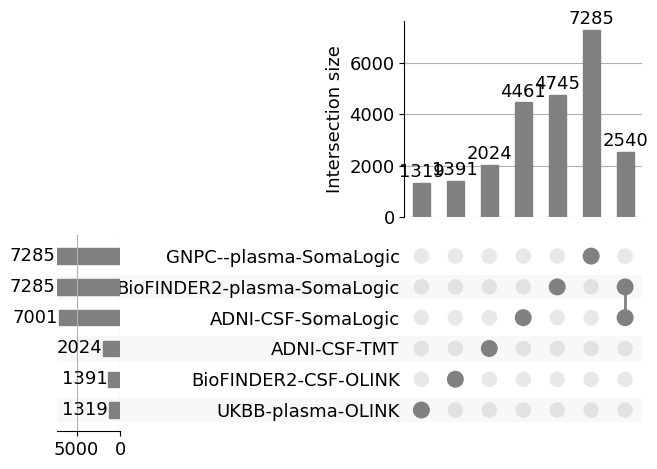

In [5]:
data = from_contents(
    {
     "GNPC--plasma-SomaLogic": set(gnpc_e4_ad.apoe_result.data['Protein_id'].tolist()), 
        "BioFINDER2-plasma-SomaLogic": set(bf2soma_e4_ab.apoe_result.data['Protein_id'].tolist()), 
        "ADNI-CSF-SomaLogic": set(adni_e4_ab.apoe_result.data['Protein_id'].tolist()), 
        "ADNI-CSF-TMT": set(adnitmt_e4_ab.apoe_result.data['Protein_id'].tolist()),
        "BioFINDER2-CSF-OLINK": set(bf2olink_e4_ab.apoe_result.data['Protein_id'].tolist()), 
        "UKBB-plasma-OLINK": set(ukbb_e4.apoe_result.data['Protein_id'].tolist())
     }
)

plt.rcParams['font.size'] = 13

upset = UpSet(data, sort_categories_by='-input', facecolor='grey', subset_size="count", show_counts=True) #shading_color="lightgrey",'
upset.plot(fig=plt.figure(figsize=(12, 4)))

fig = plt.figure(figsize=(13, 4))
fig.subplots_adjust(left=0.1, right=0.99, top=0.88, bottom=0.10)
upset.plot(fig=fig)

plt.suptitle("Shared proteins in each dataset", fontsize=15)

plt.close(fig)

In [6]:
Results = copy.deepcopy(bf2olink_e2_ab)

count = 0
for x,c in Counter(Results.apoe_result.data['symbol'].tolist()).items():
    if c > 1:
        count += 1
count

3

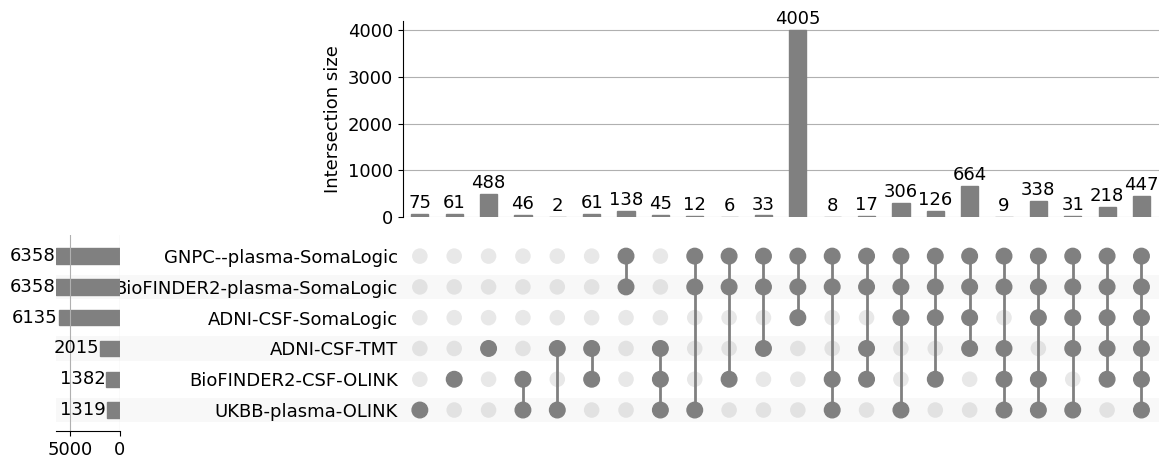

In [7]:
data = from_contents(
    {
     "GNPC--plasma-SomaLogic": set(gnpc_e4_ad.apoe_result.data['symbol'].tolist()), 
        "BioFINDER2-plasma-SomaLogic": set(bf2soma_e4_ab.apoe_result.data['symbol'].tolist()), 
        "ADNI-CSF-SomaLogic": set(adni_e4_ab.apoe_result.data['symbol'].tolist()), 
        "ADNI-CSF-TMT": set(adnitmt_e4_ab.apoe_result.data['symbol'].tolist()),
        "BioFINDER2-CSF-OLINK": set(bf2olink_e4_ab.apoe_result.data['symbol'].tolist()), 
        "UKBB-plasma-OLINK": set(ukbb_e4.apoe_result.data['symbol'].tolist())
     }
)

plt.rcParams['font.size'] = 13

upset = UpSet(data, sort_categories_by='-input', facecolor='grey', subset_size="count", show_counts=True) #shading_color="lightgrey",'
upset.plot(fig=plt.figure(figsize=(12, 4)))

fig = plt.figure(figsize=(13, 4))
fig.subplots_adjust(left=0.1, right=0.99, top=0.88, bottom=0.10)
upset.plot(fig=fig)

plt.suptitle("Shared proteins in each dataset", fontsize=15)
plt.savefig('../Figs/other/sup_fig3a.svg', format='svg', dpi=600, bbox_inches='tight')

plt.close(fig)

<Figure size 1200x400 with 0 Axes>

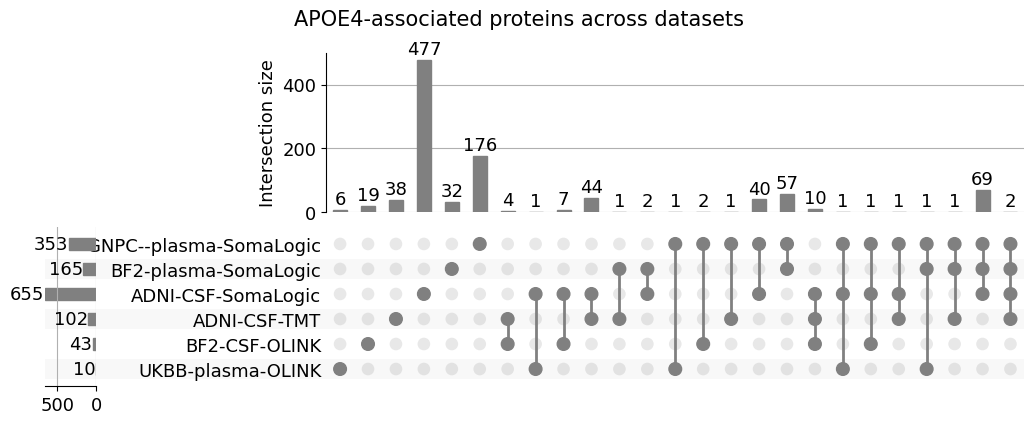

In [8]:
data = from_contents(
    {
     "GNPC--plasma-SomaLogic": set([gnpc_e4_ad.id2symbol[x] for x in gnpc_e4_ad.apoe_result.sig]), 
        "BF2-plasma-SomaLogic": set([bf2soma_e4_ab.id2symbol[x] for x in bf2soma_e4_ab.apoe_result.sig]), 
        "ADNI-CSF-SomaLogic": set([adni_e4_ab.id2symbol[x] for x in adni_e4_ab.apoe_result.sig]),
        "ADNI-CSF-TMT": set([adnitmt_e4_ab.id2symbol[x] for x in adnitmt_e4_ab.apoe_result.sig]),
        "BF2-CSF-OLINK": set([bf2olink_e4_ab.id2symbol[x] for x in bf2olink_e4_ab.apoe_result.sig]), 
        "UKBB-plasma-OLINK": set([ukbb_e4.id2symbol[x] for x in ukbb_e4.apoe_result.sig]),
     }
)

plt.rcParams['font.size'] = 13
upset = UpSet(data, sort_categories_by='-input', facecolor='grey', subset_size="count", show_counts=True, element_size=26) #shading_color="lightgrey",

fig = plt.figure(figsize=(12, 4))
fig.subplots_adjust(left=0.1, right=0.99, top=0.88, bottom=0.10)
upset.plot(fig=plt.figure(figsize=(12, 4)))

plt.suptitle("APOE4-associated proteins across datasets", fontsize=15)
plt.savefig('../Figs/other/apoe4_associated.svg', format='svg', dpi=600, bbox_inches='tight')

plt.show()

<Figure size 1200x400 with 0 Axes>

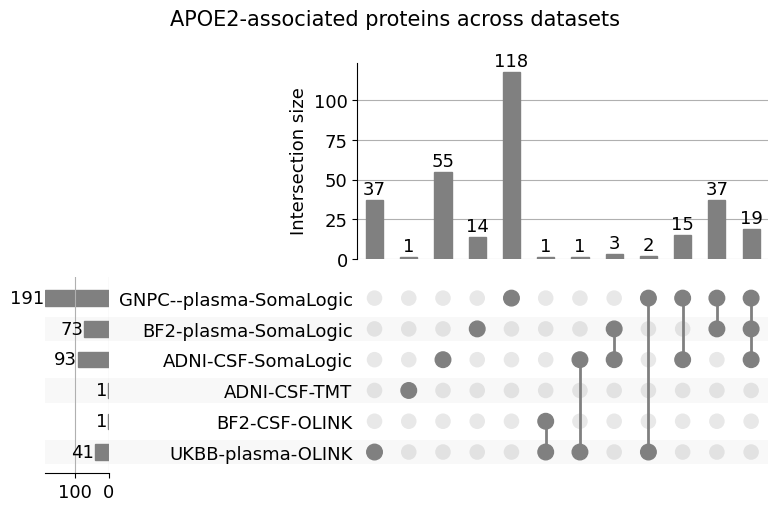

In [9]:
data = from_contents(
    {
     "GNPC--plasma-SomaLogic": set([gnpc_e2_ad.id2symbol[x] for x in gnpc_e2_ad.apoe_result.sig]), 
        "BF2-plasma-SomaLogic": set([bf2soma_e2_ab.id2symbol[x] for x in bf2soma_e2_ab.apoe_result.sig]), 
        "ADNI-CSF-SomaLogic": set([adni_e2_ab.id2symbol[x] for x in adni_e2_ab.apoe_result.sig]), 
        "ADNI-CSF-TMT": set([adnitmt_e2_ab.id2symbol[x] for x in adnitmt_e2_ab.apoe_result.sig]),
        "BF2-CSF-OLINK": set([bf2olink_e2_ab.id2symbol[x] for x in bf2olink_e2_ab.apoe_result.sig]), 
        "UKBB-plasma-OLINK": set([ukbb_e2.id2symbol[x] for x in ukbb_e2.apoe_result.sig]),
     }
)
plt.rcParams['font.size'] = 13
upset = UpSet(data, sort_categories_by='-input', facecolor='grey', subset_size="count", show_counts=True) #shading_color="lightgrey",

fig = plt.figure(figsize=(12,4))
upset.plot(fig=plt.figure(figsize=(12,4)))

#fig.subplots_adjust(left=0.1, right=0.99, top=0.88, bottom=0.10)
plt.suptitle("APOE2-associated proteins across datasets", fontsize=15)
plt.savefig('../Figs/other/apoe2_associated.svg', format='svg', dpi=600, bbox_inches='tight')

plt.show()

# Summarize for one dataset

## Basic checking

In [30]:
apoe4incu_adine3e3 = gnpc_e4_ad.neg_allage.sig & gnpc_e4_ad.ad_ine3e3.sig
merged = pd.merge(gnpc_e4_ad.neg_allage.data[gnpc_e4_ad.neg_allage.data['ref_name'].isin(apoe4incu_adine3e3)][['ref_name', 'standardized_beta']],
         gnpc_e4_ad.ad_ine3e3.data[gnpc_e4_ad.ad_ine3e3.data['ref_name'].isin(apoe4incu_adine3e3)][['ref_name', 'standardized_beta']], on='ref_name', how='inner')
merged['direction'] = merged['standardized_beta_x'] * merged['standardized_beta_y']
merged['direction'] = merged['direction'].apply(lambda x: 'opposite' if x < 0 else 'same')
Counter(merged['direction'])

Counter({'opposite': 48, 'same': 18})

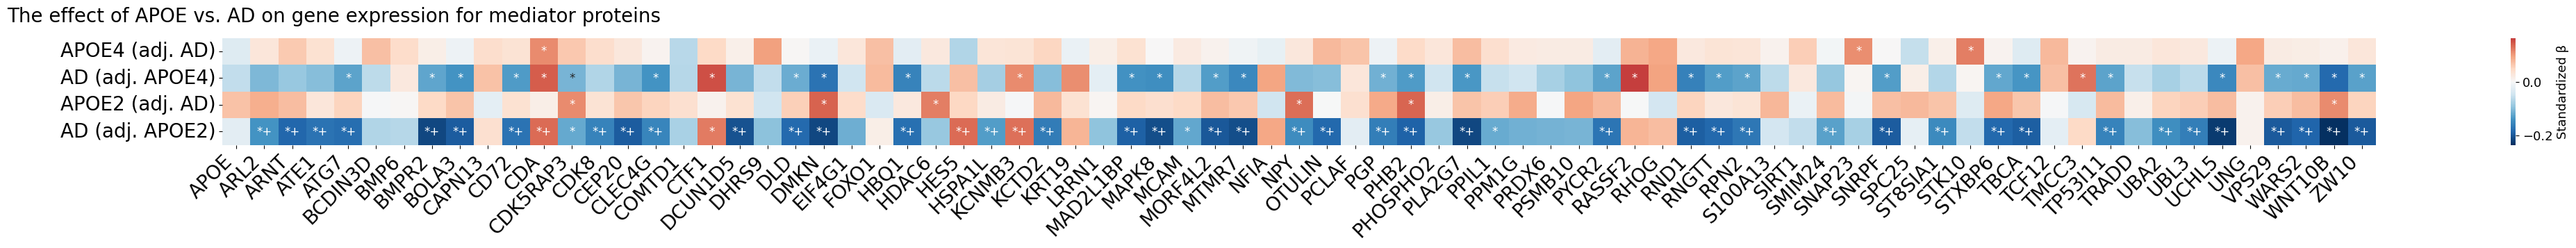

In [132]:
Result1 = copy.deepcopy(rosmap_e4)
Result2 = copy.deepcopy(rosmap_e2)
pc1 = rosmap_e4.apoe_result.data['Protein_id'].tolist()
title_ = f'The effect of APOE vs. AD on gene expression for mediator proteins'

models_df = pd.DataFrame({'Protein_id': list(pc1)})
models_df['label'] = models_df['Protein_id'].apply(lambda x: Result1.id2symbol[x])

tmp = Result1.apoe_adj_result.data[Result1.apoe_adj_result.data['Protein_id'].isin(pc1)][['Protein_id','standardized_beta', 'significance', 'label']]
tmp.rename(columns={'standardized_beta':'β2 APOE4'}, inplace=True)
tmp.rename(columns={'significance':'p2 APOE4'}, inplace=True)
models_df = pd.merge(models_df, tmp, on=['Protein_id', 'label'], how='left')

tmp = Result1.pathology_adj_result.data[Result1.pathology_adj_result.data['Protein_id'].isin(pc1)][['Protein_id','standardized_beta', 'significance', 'label']]
tmp.rename(columns={'standardized_beta':'β3 APOE4'}, inplace=True)
tmp.rename(columns={'significance':'p3 APOE4'}, inplace=True)
models_df = pd.merge(models_df, tmp, on=['Protein_id', 'label'], how='left')

tmp = Result2.apoe_adj_result.data[Result2.apoe_adj_result.data['Protein_id'].isin(pc1)][['Protein_id','standardized_beta', 'significance', 'label']]
tmp.rename(columns={'standardized_beta':'β2 APOE2'}, inplace=True)
tmp.rename(columns={'significance':'p2 APOE2'}, inplace=True)
models_df = pd.merge(models_df, tmp, on=['Protein_id', 'label'], how='left')

tmp = Result2.pathology_adj_result.data[Result2.pathology_adj_result.data['Protein_id'].isin(pc1)][['Protein_id','standardized_beta', 'significance', 'label']]
tmp.rename(columns={'standardized_beta':'β3 APOE2'}, inplace=True)
tmp.rename(columns={'significance':'p3 APOE2'}, inplace=True)
models_df = pd.merge(models_df, tmp, on=['Protein_id', 'label'], how='left')


models_df.set_index('Protein_id', inplace=True)
models_df.sort_index(axis=0, inplace=True)

models = models_df[['β2 APOE4', 'β3 APOE4', 'β2 APOE2', 'β3 APOE2']]
annotations = models_df[['p2 APOE4', 'p3 APOE4', 'p2 APOE2', 'p3 APOE2']]
models.columns = [f'{Result1.apoe_identifier} (adj. AD)', f'{Result1.pathology_identifier} (adj. APOE4)', 
                  f'{Result2.apoe_identifier} (adj. AD)', f'{Result2.pathology_identifier} (adj. APOE2)']

plt.figure(figsize=(50, 2))
ax = sns.heatmap(models.T, center=0, cmap='RdBu_r', cbar_kws={'label': 'Standardized β'}, 
                 annot_kws={"fontsize": 12,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=annotations.T, fmt='')

plt.rcParams['font.size'] = 20

plt.gca().grid(False)
plt.xlabel('')
plt.ylabel('')
plt.text(-0.1, 1.2, title_, fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

xticks = ax.xaxis.get_major_ticks()
labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticklabels([Result1.id2symbol[x] for x in labels])

plt.xticks(rotation=45, ha='right', va='top')
plt.yticks(rotation=0)

plt.show()

#ax.figure.savefig("../Figs/GNPC/somalogic.svg", format='svg', dpi=600, bbox_inches='tight')

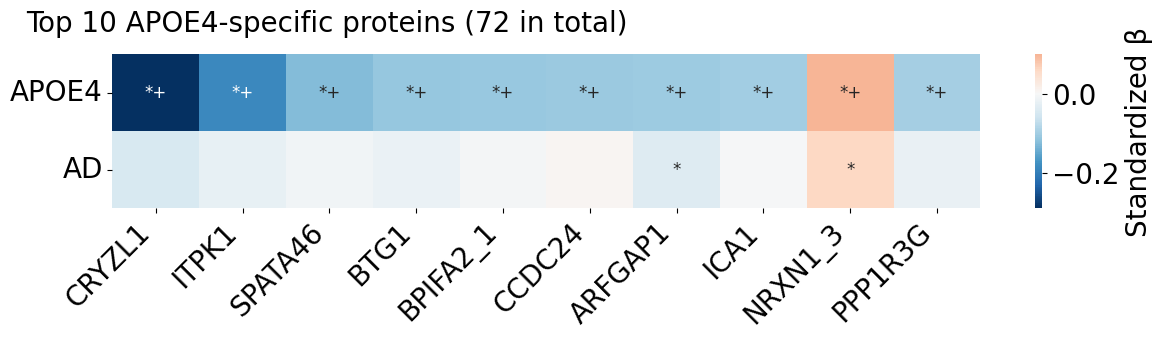

In [11]:
Result = copy.deepcopy(gnpc_e4_ad)
pc1 = Result.apoe_solo_final
title_ = f'Top 10 {Result.apoe_identifier}-specific proteins ({len(pc1)} in total)'

models_df = pd.DataFrame({Result.summarize_oncol: list(pc1)})
models_df['label'] = models_df[Result.summarize_oncol].apply(lambda x: Result.id2label[x])

tmp = Result.apoe_result.data[Result.apoe_result.data[Result.summarize_oncol].isin(pc1)][[Result.summarize_oncol,'standardized_beta', 'significance', 'label']]
tmp.rename(columns={'standardized_beta':'β2'}, inplace=True)
tmp.rename(columns={'significance':'p2'}, inplace=True)
models_df = pd.merge(models_df, tmp, on=[Result.summarize_oncol, 'label'], how='left')

tmp = Result.pathology_result.data[Result.pathology_result.data[Result.summarize_oncol].isin(pc1)][[Result.summarize_oncol,'standardized_beta', 'significance', 'label']]
tmp.rename(columns={'standardized_beta':'β3'}, inplace=True)
tmp.rename(columns={'significance':'p3'}, inplace=True)
models_df = pd.merge(models_df, tmp, on=[Result.summarize_oncol, 'label'], how='left')

models_df['abs_beta1'] = abs(models_df['β2'])
models_df['abs_beta2'] = abs(models_df['β3'])
models_df = models_df.sort_values(by=['abs_beta1'], ascending=False)

models_df = models_df.head(10)

models_df.set_index(Result.summarize_oncol, inplace=True)

models = models_df[['β2', 'β3']]
annotations = models_df[['p2', 'p3']]
models.columns = [f'{Result.apoe_identifier}', f'{Result.pathology_identifier}']

plt.figure(figsize=(14, 2))
ax = sns.heatmap(models.T, center=0, cmap='RdBu_r', cbar_kws={'label': 'Standardized β'}, 
                 annot_kws={"fontsize": 12,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=annotations.T, fmt='')

plt.rcParams['font.size'] = 20

plt.gca().grid(False)
plt.xlabel('')
plt.ylabel('')
plt.text(-0.1, 1.2, title_, fontsize=20, ha='left', va='center', transform=plt.gca().transAxes)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

xticks = ax.xaxis.get_major_ticks()
labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticklabels([Result.id2label[x] for x in labels])

plt.xticks(rotation=45, ha='right', va='top')
plt.yticks(rotation=0)

plt.show()

#ax.figure.savefig("../Figs/GNPC/somalogic.svg", format='svg', dpi=600, bbox_inches='tight')

/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_1861/2018560748.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


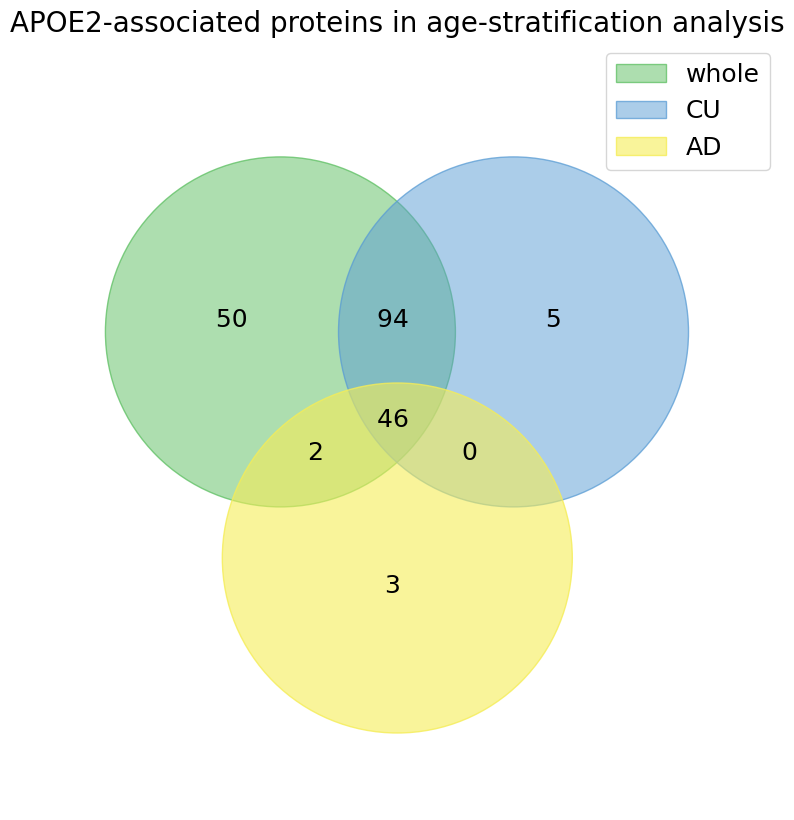

In [13]:
set1 = gnpc_e2_ad.apoe_result.sig
set2 = gnpc_e2_ad.neg_allage.sig
set3 = gnpc_e2_ad.pos_allage.sig

plt.rcParams['font.size'] = 20
labels = venn.get_labels([set1, set2, set3], fill=['number'])

fig, ax = venn.venn3(labels, names=['whole', 
                                    'CU',
                                    'AD'], figsize=(10, 10), fontsize=18)

plt.title("APOE2-associated proteins in age-stratification analysis",fontsize=20)

fig.show()

In [14]:
tmp = gnpc_e4_ad.pathology_mediation.data[gnpc_e4_ad.pathology_mediation.data['ref_name'].isin(gnpc_e4_ad.path2_part)]
tmp['abs'] = abs(tmp['prop_m'])
tmp.sort_values('abs', ascending=False, inplace=True)
tmp[['symbol', 'prop_m', 'p_adjusted', 'prop_m_p_adjusted', 'ade_p_adjusted']]

,symbol,prop_m,p_adjusted,prop_m_p_adjusted,ade_p_adjusted
73,RAB14,-0.699495,0.000000,0.004958,0.000000
187,HES5,-0.592829,0.000000,0.000000,0.000000
215,GMPPA,-0.563928,0.000000,0.000000,0.000000
104,SARS1,-0.524634,0.000000,0.000000,0.000000
236,FXYD6,0.501753,0.000000,0.000000,0.044921
...,...,...,...,...,...
288,MENT,0.063039,0.011966,0.012170,0.000000
131,MAGEA3,0.062224,0.000000,0.000000,0.000000
352,IFIT2,-0.060955,0.043991,0.043991,0.000000
99,DHRS9,-0.054894,0.034660,0.034829,0.000000


In [15]:
tmp = bf2olink_e4_ab.protein_mediation.data[bf2olink_e4_ab.protein_mediation.data['Protein_id'].isin(bf2olink_e4_ab.path1_proteins)]
tmp['abs'] = abs(tmp['prop_m'])
tmp.sort_values('abs', ascending=False, inplace=True)
tmp[['symbol', 'prop_m', 'prop_m_p_adjusted', 'ade_p_adjusted']]

,symbol,prop_m,prop_m_p_adjusted,ade_p_adjusted
2,CKAP4,-0.016744,0.044387,0


In [16]:
ad_ine3e3_sig = set(gnpc_e4_ad.ad_ine3e3.data[gnpc_e4_ad.ad_ine3e3.data['p_adjusted']<0.05]['ref_name'].tolist())
apoe4incu_adine3e3 = ad_ine3e3_sig & gnpc_e4_ad.neg_allage.sig
merged = pd.merge(gnpc_e4_ad.neg_allage.data[gnpc_e4_ad.neg_allage.data['ref_name'].isin(apoe4incu_adine3e3)][['ref_name', 'standardized_beta']],
         gnpc_e4_ad.ad_ine3e3.data[gnpc_e4_ad.ad_ine3e3.data['ref_name'].isin(apoe4incu_adine3e3)][['ref_name', 'standardized_beta']], on='ref_name', how='inner')
merged['direction'] = merged['standardized_beta_x'] * merged['standardized_beta_y']
merged['direction'] = merged['direction'].apply(lambda x: 'opposite' if x < 0 else 'same')
Counter(merged['direction'])

Counter({'opposite': 48, 'same': 18})

In [17]:
merged['abs_apoe4'] = abs(merged['standardized_beta_x'])
merged['abs_ad'] = abs(merged['standardized_beta_y'])
merged['apoe_dominant'] = merged['abs_apoe4'] > merged['abs_ad']
set(merged[merged['apoe_dominant'] == True]['ref_name'].tolist()) & gnpc_e4_ad.path1_proteins

{'ARL2__seq.12587.65',
 'OTULIN__seq.21916.82',
 'SNRPF__seq.5494.52',
 'VPS29__seq.14318.1',
 'ZW10__seq.25262.6'}

In [18]:
# Only a minority showed opposite regulation (Fig. 4c), with ε4-dominant (e.g., PHGDH, FOXO1) or ε2-dominant (e.g., VPS29, BIRC2) patterns (Fig. 4d). Most shared proteins (e.g., S100A13, BCDIN3D, TBCA, ARL2) changed in the same direction
merged = pd.merge(gnpc_e4_ad.apoe_result.data[gnpc_e4_ad.apoe_result.data['ref_name'].isin(gnpc_e4_ad.neg_allage.sig & gnpc_e2_ad.neg_allage.sig)][['ref_name', 'standardized_beta']],
         gnpc_e2_ad.apoe_result.data[gnpc_e2_ad.apoe_result.data['ref_name'].isin(gnpc_e4_ad.neg_allage.sig & gnpc_e2_ad.neg_allage.sig)][['ref_name', 'standardized_beta']], on='ref_name', how='inner')
merged['direction'] = merged['standardized_beta_x'] * merged['standardized_beta_y']
merged['direction'] = merged['direction'].apply(lambda x: 'opposite' if x < 0 else 'same')
Counter(merged['direction'])

Counter({'same': 64, 'opposite': 13})

/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_1861/1910249447.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


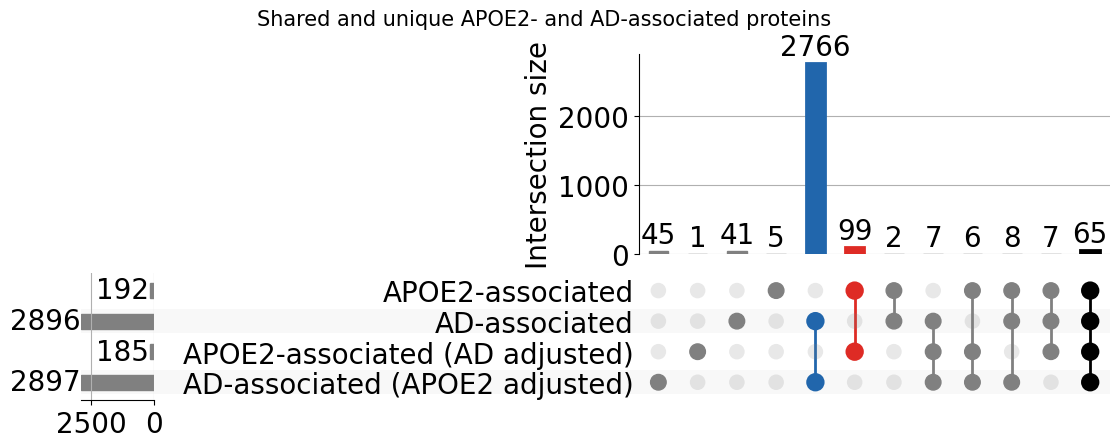

In [19]:
Results = copy.deepcopy(gnpc_e2_ad)

data = from_contents(
    {
     f"{Results.apoe_identifier}-associated": Results.apoe_result.sig, 
        f"{Results.pathology_identifier}-associated": Results.pathology_result.sig, 
        f"{Results.apoe_identifier}-associated ({Results.pathology_identifier} adjusted)": Results.apoe_adj_result.sig, 
        f"{Results.pathology_identifier}-associated ({Results.apoe_identifier} adjusted)": Results.pathology_adj_result.sig, 
     }
)

upset = UpSet(data, sort_categories_by='-input', facecolor='grey', subset_size="count", show_counts=True) #shading_color="lightgrey",
upset.style_subsets(present=[f"{Results.apoe_identifier}-associated", f"{Results.apoe_identifier}-associated ({Results.pathology_identifier} adjusted)"],
                    absent=[f"{Results.pathology_identifier}-associated", f"{Results.pathology_identifier}-associated ({Results.apoe_identifier} adjusted)"],
                    facecolor="#DE2B25", linewidth=2)
upset.style_subsets(present=[f"{Results.pathology_identifier}-associated", f"{Results.pathology_identifier}-associated ({Results.apoe_identifier} adjusted)"],
                    absent=[f"{Results.apoe_identifier}-associated", f"{Results.apoe_identifier}-associated ({Results.pathology_identifier} adjusted)"],
                    facecolor="#2166ACFF", linewidth=2)
upset.style_subsets(present=[f"{Results.apoe_identifier}-associated", f"{Results.apoe_identifier}-associated ({Results.pathology_identifier} adjusted)", f"{Results.pathology_identifier}-associated", f"{Results.pathology_identifier}-associated ({Results.apoe_identifier} adjusted)"],
                    facecolor="black", linewidth=2)

fig = plt.figure(figsize=(12, 4))
fig.subplots_adjust(left=0.1, right=0.99, top=0.88, bottom=0.10)
upset.plot(fig=fig)

plt.suptitle(f"Shared and unique {Results.apoe_identifier}- and {Results.pathology_identifier}-associated proteins",fontsize=15)
plt.tight_layout()
plt.show()
fig.savefig(f"../Figs/{Results.fig_folder}/upset_{Results.apoe_identifier}vs{Results.pathology_identifier}.svg", format='svg', dpi=600, bbox_inches='tight')

/Users/li7186lu/Library/Python/3.14/lib/python/site-packages/venn/_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((
/Users/li7186lu/Library/Python/3.14/lib/python/site-packages/venn/_backwards_compatibility.py:30: UserWarning: `venn4()` is retained for backwards compatibility; use `venn()` instead
  warn((
/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_1861/2408045079.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


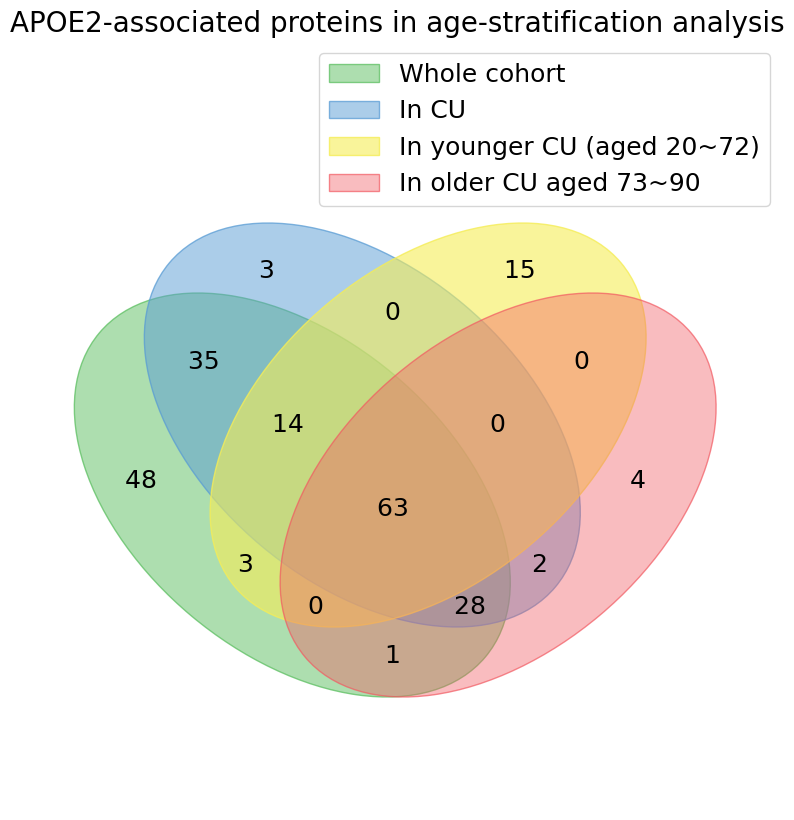

In [20]:
set1 = gnpc_e2_ad.apoe_result.sig
set2 = gnpc_e2_ad.neg_allage.sig
set3 = gnpc_e2_ad.neg_younger.sig
set4 = gnpc_e2_ad.neg_older.sig

plt.rcParams['font.size'] = 20
labels = venn.get_labels([set1, set2, set3, set4], fill=['number'])

fig, ax = venn.venn4(labels, names=['Whole cohort', 
                                    'In CU',
                                    'In younger CU (aged 20~72)',
                                    'In older CU aged 73~90'], figsize=(10, 10), fontsize=18)

plt.title("APOE2-associated proteins in age-stratification analysis",fontsize=20)

fig.show()

/Users/li7186lu/Library/Python/3.14/lib/python/site-packages/venn/_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((
/Users/li7186lu/Library/Python/3.14/lib/python/site-packages/venn/_backwards_compatibility.py:30: UserWarning: `venn4()` is retained for backwards compatibility; use `venn()` instead
  warn((
/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_1195/868166921.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


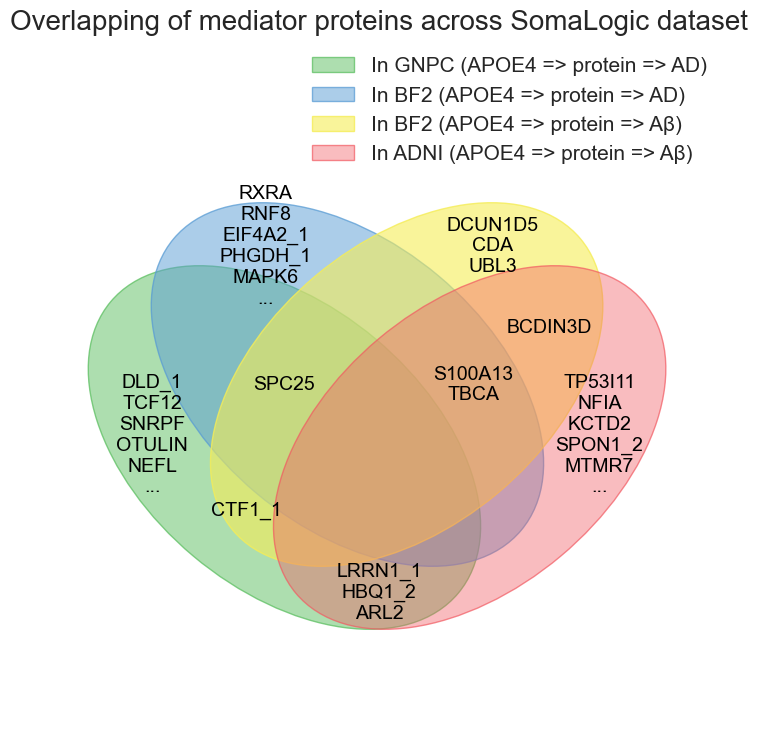

In [130]:
set1 = gnpc_e4_ad.path1_proteins
set2 = bf2soma_e4_ad.path1_proteins
set3 = bf2soma_e4_ab.path1_proteins
set4 = adni_e4_ab.path1_proteins
labels = venn.get_labels([set1, set2, set3, set4], fill=['number'])
labels['1111'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set1&set2&set3&set4)}'
labels['0111'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set2&set3&set4-set1)}'
labels['1000'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set1-set2-set3-set4)}'
labels['0100'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set2-set1-set3-set4)}'
labels['1010'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set1&set3-set2-set4)}'
labels['1110'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set1&set2&set3-set4)}'
labels['0011'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set3&set4-set1-set2)}'
labels['1001'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set1&set4-set2-set3)}'
labels['0010'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set3-set1-set2-set4)}'
labels['0001'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set4-set1-set2-set3)}'

for k in labels.keys():
    if labels[k] == '0 ':
        labels[k] = ' '
    if len(labels[k].split('\n')) > 5:
        labels[k] = '\n'.join(labels[k].split('\n')[:5]) + '\n...'

fig, ax = venn.venn4(labels, names=['In GNPC (APOE4 => protein => AD)', 
                                    'In BF2 (APOE4 => protein => AD)',
                                    'In BF2 (APOE4 => protein => Aβ)',
                                    'In ADNI (APOE4 => protein => Aβ)'])

patches = ax.patches[:4] 

labels_for_legend = ['In GNPC (APOE4 => protein => AD)', 
                                    'In BF2 (APOE4 => protein => AD)',
                                    'In BF2 (APOE4 => protein => Aβ)',
                                    'In ADNI (APOE4 => protein => Aβ)']

ax.legend(
    handles=patches,
    labels=labels_for_legend,
    loc="best",
    fontsize=15,
    frameon=False
)

plt.title("Overlapping of mediator proteins across SomaLogic dataset",fontsize=20)

fig.show()

fig.savefig(f"../Figs/other/fig6b.svg", format='svg', dpi=600, bbox_inches='tight')
#Source data
all_proteins = sorted(set1 | set2 | set3 | set4)

source_membership = pd.DataFrame({
    "protein_id": all_proteins,
    "protein_label": [gnpc_e4_ad.id2label.get(x, x) for x in all_proteins],
    "GNPC_APOE4_protein_AD": [int(x in set1) for x in all_proteins],
    "BF2_APOE4_protein_AD": [int(x in set2) for x in all_proteins],
    "BF2_APOE4_protein_Aβ": [int(x in set3) for x in all_proteins],
    "ADNI_APOE4_protein_Aβ": [int(x in set4) for x in all_proteins],
})

source_membership.to_excel('../SourceData/Fig_6b.xlsx')

C:\Users\li7186lu\AppData\Local\Temp\ipykernel_13556\2336854896.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


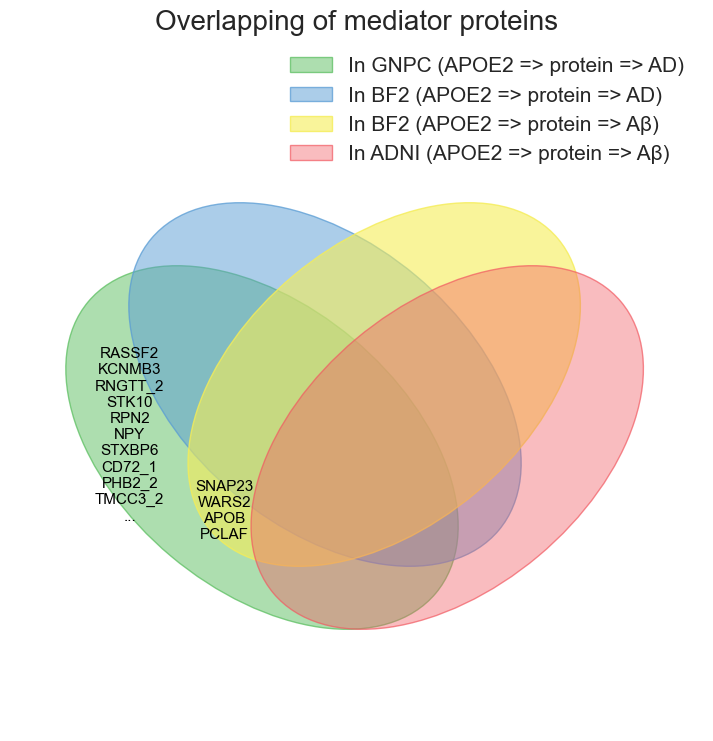

In [41]:
set1 = gnpc_e2_ad.path1_proteins
set2 = bf2soma_e2_ad.path1_proteins
set3 = bf2soma_e2_ab.path1_proteins
set4 = adni_e2_ab.path1_proteins
labels = venn.get_labels([set1, set2, set3, set4], fill=['number'])
labels['1000'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set1-set2-set3-set4)}'
labels['1010'] = f'{'\n'.join(gnpc_e4_ad.id2label[x] for x in set1&set3-set2-set4)}'

for k in labels.keys():
    if labels[k] == '0 ':
        labels[k] = ' '
    if len(labels[k].split('\n')) > 10:
        labels[k] = '\n'.join(labels[k].split('\n')[:10]) + '\n...'

fig, ax = venn.venn4(labels, names=['In GNPC (APOE2 => protein => AD)', 
                                    'In BF2 (APOE2 => protein => AD)',
                                    'In BF2 (APOE2 => protein => Aβ)',
                                    'In ADNI (APOE2 => protein => Aβ)'])

patches = ax.patches[:4] 

labels_for_legend = ['In GNPC (APOE2 => protein => AD)', 
                                    'In BF2 (APOE2 => protein => AD)',
                                    'In BF2 (APOE2 => protein => Aβ)',
                                    'In ADNI (APOE2 => protein => Aβ)']

ax.legend(
    handles=patches,
    labels=labels_for_legend,
    loc="best",
    fontsize=15,
    frameon=False
)

for text in ax.texts:
    text.set_fontsize(11)

for text in ax.texts:
    if "NEFL" in text.get_text():
        x, y = text.get_position()
        text.set_position((x-0.06, y-0.05))
    if "FOXO1" in text.get_text():
        x, y = text.get_position()
        text.set_position((x+0.1, y))
    if "WARS1" in text.get_text():
        x, y = text.get_position()
        text.set_position((x-0.03, y+0.02))

plt.title("Overlapping of mediator proteins",fontsize=20)

fig.show()

# for text in ax.texts:
#     print(text.get_text(), text.get_position())



#fig.savefig("../../Figs/ADNI/fig6b.svg", format='svg', dpi=600, bbox_inches='tight')

## Mediation plots

In [23]:
Results = copy.deepcopy(gnpc_e4_ad)
tmp = Results.protein_mediation.data[Results.protein_mediation.data[Results.summarize_oncol].isin(Results.path1_proteins)]
tmp['abs'] = abs(tmp['prop_m'])
tmp.sort_values('abs', ascending=False, inplace=True)
tmp[['symbol', 'prop_m']]

,symbol,prop_m
195,SPC25,0.489558
18,LRRN1,0.207704
37,ARL2,0.204531
3,NEFL,0.156347
233,ZW10,-0.125544
161,ST8SIA1,-0.123893
64,CTF1,0.089747
74,VPS29,-0.089386
320,HBQ1,-0.074662
178,OTULIN,-0.071924


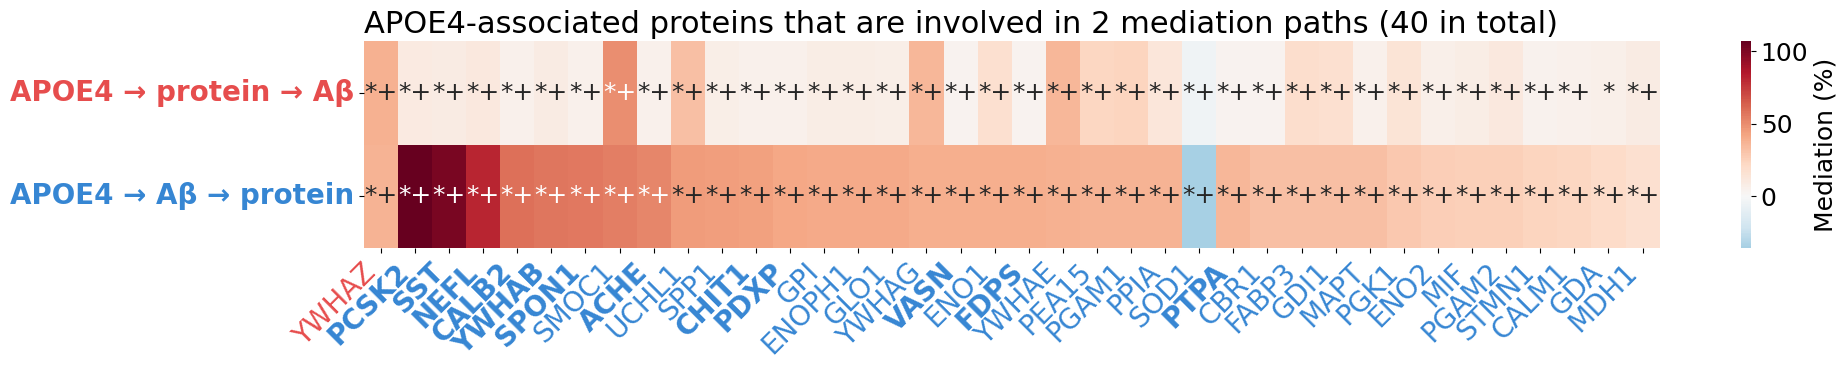

In [24]:
Results = copy.deepcopy(adnitmt_e4_ab)
pc2 = Results.path1_proteins | Results.path2_proteins

mediations, annotations, types = utils.mediation_heatmap_data(Results, pc2, 50, 0.1)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 20
plt.figure(figsize=(0.55*len(mediations.index), 1.1))

colors = ["blue","white", "#DC0000B2"]
cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", colors, N=256)

ax = sns.heatmap(mediations.T, center=0, cmap='RdBu_r', cbar=True, 
                 cbar_kws={'label': 'Mediation (%)', 'shrink': 1}, 
                 linewidths=0, annot=annotations.T, fmt='',
                 annot_kws={"fontsize": 18, "ha": "center", "va": "center"})

plt.gca().grid(False)
plt.xlabel('')
plt.ylabel('')

plt.title(f'{Results.apoe_identifier}-associated proteins that are involved in 2 mediation paths ({len(pc2)} in total)', fontsize=22,loc='left')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

proteinticks = ax.xaxis.get_major_ticks()
proteinlabels = [label.get_text() for label in ax.get_xticklabels()]

pathticks = ax.yaxis.get_major_ticks()
pathlabels = [label.get_text() for label in ax.get_yticklabels()]

for tick, label in zip(proteinticks, proteinlabels):
    if types[label] == 'protein total':
        tick.label1.set_color('#DC0000B2')
        tick.label1.set_fontweight('bold')
    elif types[label] == 'protein partial':
        tick.label1.set_color('#DC0000B2')
    elif types[label] == 'ad total':
        tick.label1.set_color('#3686D3')
        tick.label1.set_fontweight('bold')
    elif types[label] == 'ad partial':
        tick.label1.set_color('#3686D3')
    else:
        tick.label1.set_color('black')

for tick, label in zip(pathticks, pathlabels):
    if label == f'{Results.apoe_identifier} → protein → {Results.pathology_identifier}':
        tick.label1.set_color("#DC0000B2")
        tick.label1.set_fontweight('bold')
    else:
        tick.label1.set_color('#3686D3')
        tick.label1.set_fontweight('bold')

ax.set_xticklabels([Results.id2label[x] for x in proteinlabels])
ax.figure.subplots_adjust(bottom=-1)

plt.xticks(rotation=45, ha='right', va='top')
plt.yticks(rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Mediation (%)', size=18)

plt.show()
ax.figure.savefig(f"../Figs/{Results.fig_folder}/heatmap_mediation_{Results.apoe_identifier}2{Results.pathology_identifier.replace('/', '')}.svg", format='svg', dpi=300, bbox_inches='tight')

/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_1861/1079554098.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([Results.id2label[x] for x in proteinlabels])


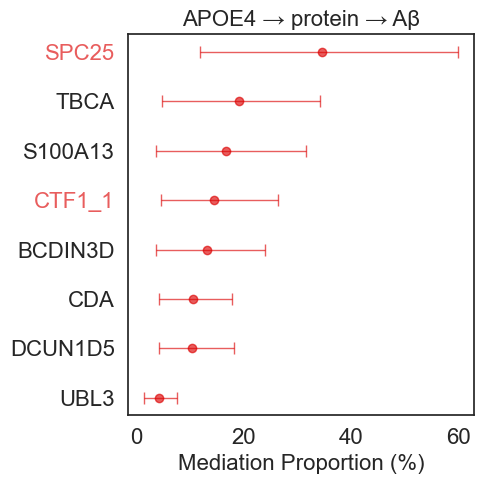

In [25]:
Results = copy.deepcopy(bf2soma_e4_ab)
validation = copy.deepcopy(gnpc_e4_ad)

sns.set(style="white")

df = Results.protein_mediation.data[Results.protein_mediation.data[Results.summarize_oncol].isin(Results.path1_proteins)]
df = df.sort_values('prop_m', ascending=True)
#df = df.tail(10)

df['error_minus'] = df['prop_m'] - df['prop_m_ci_lower']
df['error_plus'] = df['prop_m_ci_upper'] - df['prop_m']

fig, ax = plt.subplots(figsize=(5, 5))

for idx, row in df.iterrows():
    ax.errorbar(
        x=row['prop_m']*100,
        y=row[Results.summarize_oncol],
        xerr=[[row['error_minus']*100], [row['error_plus']*100]],
        fmt='o',
        color='#DC0000A2' if row['prop_m_p_adjusted'] < 0.05 else 'gray',
        capsize=4,
        markersize=6,
        elinewidth=1
    )

proteinticks = ax.yaxis.get_major_ticks()
proteinlabels = [label.get_text() for label in ax.get_yticklabels()]

for tick, label in zip(proteinticks, proteinlabels):
    if label in Results.path1_full:
        tick.label1.set_fontweight('bold')
    if validation is not None and label in validation.path1_proteins:
        tick.label1.set_color('#DC0000A2')
    else:
        pass

ax.set_yticklabels([Results.id2label[x] for x in proteinlabels])
ax.tick_params(labelsize=16)
#ax.axvline(0, color='black', linestyle='--', lw=1)
ax.set_xlabel("Mediation Proportion (%)", fontsize=16)
extra = f'\n(adjustment for Results.sensitivity)' if Results.sensitivity != '' else ''
ax.set_title(f"{Results.apoe_identifier} → protein → {Results.pathology_identifier}{extra}", fontsize=16)
plt.tight_layout()
plt.show()
ax.figure.savefig(f"../Figs/{Results.fig_folder}/errorbar_mediation_{Results.apoe_identifier}2{Results.pathology_identifier.replace('/', '')}{Results.sensitivity}.svg", format='svg', dpi=600, bbox_inches='tight')

## Subdivision

/Users/li7186lu/Library/Python/3.14/lib/python/site-packages/venn/_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((
/Users/li7186lu/Library/Python/3.14/lib/python/site-packages/venn/_backwards_compatibility.py:30: UserWarning: `venn4()` is retained for backwards compatibility; use `venn()` instead
  warn((
/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_1861/1385215274.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


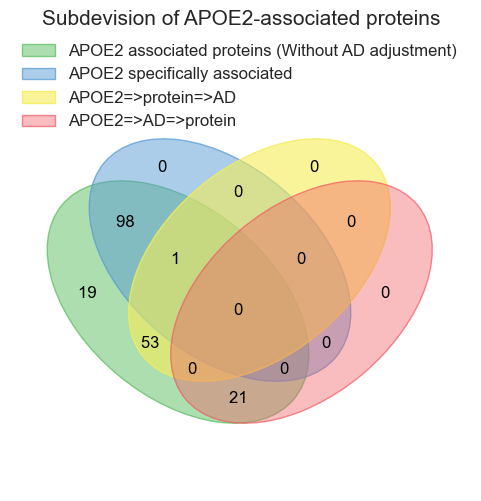

In [26]:
Results = copy.deepcopy(gnpc_e2_ad)
set1 = Results.apoe_result.sig
set2 = Results.apoe_solo
set3 = Results.path1_proteins
set4 = Results.path2_proteins

labels = venn.get_labels([set1, set2, set3, set4], fill=['number'])

fig, ax = venn.venn4(labels, names=[f'{Results.apoe_identifier} assocated proteins(Without {Results.pathology_identifier} adjustment)', 
                                    f'{Results.apoe_identifier} specifically associated', f'{Results.apoe_identifier}=>protein=>{Results.pathology_identifier}', 
                                    f'{Results.apoe_identifier}=>{Results.pathology_identifier}=>protein'],
                                    figsize=(6, 6),
                                    fontsize=12)
patches = ax.patches[:4] 

labels_for_legend = [
    f'{Results.apoe_identifier} associated proteins (Without {Results.pathology_identifier} adjustment)', 
    f'{Results.apoe_identifier} specifically associated', 
    f'{Results.apoe_identifier}=>protein=>{Results.pathology_identifier}', 
    f'{Results.apoe_identifier}=>{Results.pathology_identifier}=>protein'
]

ax.legend(
    handles=patches,
    labels=labels_for_legend,
    loc="best",
    fontsize=12,
    frameon=False
)

#plt.legend([], frameon=False)
plt.title(f"Subdevision of {Results.apoe_identifier}-associated proteins", pad=0, fontsize=15) # x=0.45,y=0.8, 
fig.show()
fig.savefig(f"../Figs/{Results.fig_folder}/venn4__{Results.apoe_identifier}_related.svg", format='svg', dpi=300, bbox_inches='tight')

# APOE4 vs. APOE2 within one dataset

/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_1861/2820685078.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


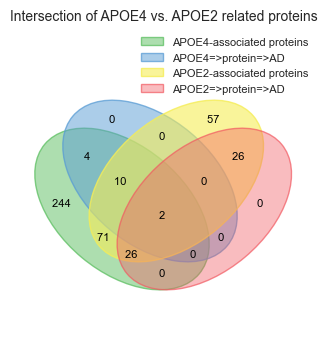

In [27]:
set1 = gnpc_e4_ad.apoe_result.sig
set2 = gnpc_e4_ad.path1_proteins
set3 = gnpc_e2_ad.apoe_result.sig
set4 = gnpc_e2_ad.path1_proteins
abad_identifier = 'AD'

col1 = list(set1)
col2 = list(set2)
col3 = list(set3)
col4 = list(set4)

labels = venn.get_labels([set1, set2, set3, set4], fill=['number'])

fig, ax = venn.venn4(labels, names=['APOE4-associated proteins', 
                                    f'APOE4=>protein=>{abad_identifier}',
                                    'APOE2-associated proteins', f'APOE2=>protein=>{abad_identifier}'],
                     figsize=(4, 4), fontsize=8)

patches = ax.patches[:4] 

labels_for_legend = ['APOE4-associated proteins', 
                                    f'APOE4=>protein=>{abad_identifier}',
                                    'APOE2-associated proteins', f'APOE2=>protein=>{abad_identifier}']

ax.legend(
    handles=patches,
    labels=labels_for_legend,
    loc="best",
    fontsize=8,
    frameon=False
)

#plt.legend([], frameon=False)
plt.title(f"Intersection of APOE4 vs. APOE2 related proteins", pad=5, fontsize=10) # x=0.45,y=0.8, 
fig.show()
fig.savefig("../Figs/GNPC/fig4a.svg", format='svg', dpi=600, bbox_inches='tight')

# Source data
all_proteins = sorted(set1 | set2 | set3 | set4)
source_membership = pd.DataFrame({
    "protein_id": all_proteins,
    "protein_label": [gnpc_e4_ad.id2label.get(x, x) for x in all_proteins],
    "APOE4_associated_proteins": [int(x in set1) for x in all_proteins],
    f"APOE4_protein_{abad_identifier}": [int(x in set2) for x in all_proteins],
    "APOE2_associated_proteins": [int(x in set3) for x in all_proteins],
    f"APOE2_protein_{abad_identifier}": [int(x in set4) for x in all_proteins],
})

source_membership.to_excel('../SourceData/Fig_4a.xlsx')

Counter({'same': 64, 'opposite': 13})


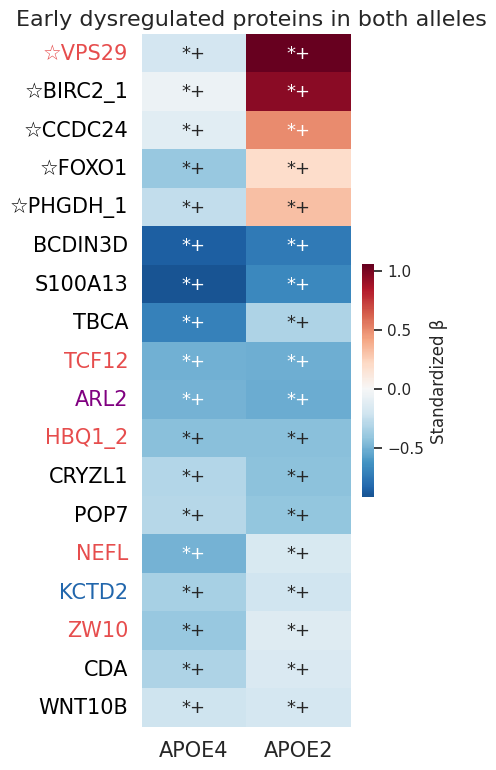

In [ ]:
Results1 = copy.deepcopy(gnpc_e4_ad)
Results2 = copy.deepcopy(gnpc_e2_ad)

lists = Results1.neg_allage.sig & Results2.neg_allage.sig
target_suffix1 = f'({Results1.neg_mark})'
target_suffix2 = f'({Results2.neg_mark})'

models, annotations, ref2bold, ref2type = utils.prepare_heatmap_inputs(lists, Results1, Results2, target_suffix1, target_suffix2, 0.2)

df = models[[f'APOE4_β{target_suffix1}',f'APOE2_β{target_suffix2}']]
annotations = annotations[[f'APOE4_p{target_suffix1}',f'APOE2_p{target_suffix2}']]

print(Counter(ref2bold.values()))

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.figure(figsize=(3, len(models)*0.5))
ax = sns.heatmap(df, center=0, cmap='RdBu_r', 
                 cbar_kws={'label': 'Standardized β', "fraction": 0.05, "aspect": 20}, 
                 annot_kws={"fontsize": 13,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=annotations, fmt='')

plt.rcParams['font.size'] = 15

plt.gca().grid(False)
plt.xlabel('')
plt.ylabel('')
plt.title(f'Early dysregulated proteins in both alleles', fontsize=16,loc = 'left', x=-0.6)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

xticks = ax.yaxis.get_major_ticks()
labels = [label.get_text() for label in ax.get_yticklabels()]

for tick, label in zip(xticks, labels):
    if label in Results1.path1_proteins & Results2.path1_proteins:
        tick.label1.set_color('purple')
    elif ref2type[label] == 'apoe4 mediator':
        tick.label1.set_color('#DC0000B2')
    elif ref2type[label] == 'apoe2 mediator':
        tick.label1.set_color('#2166ACFF')
    else:
        tick.label1.set_color('black')

ax.set_yticklabels([f'☆{Results1.id2label[x]}' if ref2bold[x] == 'opposite' else Results1.id2label[x] for x in labels])

ax.set_xticklabels(['APOE4','APOE2'])

#plt.xticks(rotation=45, ha='right', va='top')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()
ax.figure.savefig(f"../Figs/{Results1.fig_folder}/early_dys_in_both.svg", format='svg', dpi=600, bbox_inches='tight')

#Source data
tmp1 = Results1.neg_allage.data[['ref_name', 'label', 'standardized_beta','p', 'p_adjusted', 'significance']]
tmp1 = pd.merge(tmp1, 
                Results2.neg_allage.data[['ref_name', 'label', 'standardized_beta','p', 'p_adjusted', 'significance']], 
                how='inner', 
                on=['ref_name', 'label'],
                suffixes=('_APOE4', '_APOE2'))

#
tmp1 = tmp1[tmp1['ref_name'].isin(models.index.tolist())]
tmp1.to_excel(f'../SourceData/{Results1.dataset}_early_dys.xlsx')

# Summary for one protein across all dataset

In [37]:
symbol = 'NEFL'
gnpc_models = utils.return_df4onesymbol(symbol, gnpc_e4_ad)
gnpc_e2_models = utils.return_df4onesymbol(symbol, gnpc_e2_ad)
bf2soma_models = utils.return_df4onesymbol(symbol, bf2soma_e4_ab)
bf2soma_e2_models = utils.return_df4onesymbol(symbol, bf2soma_e2_ab)
adni_models = utils.return_df4onesymbol(symbol, adni_e4_ab)
adni_e2_models = utils.return_df4onesymbol(symbol, adni_e2_ab)
adnitmt_models = utils.return_df4onesymbol(symbol, adnitmt_e4_ab)
adnitmt_e2_models = utils.return_df4onesymbol(symbol, adnitmt_e2_ab)

bf2olink_models = utils.return_df4onesymbol(symbol, bf2olink_e4_ab)
bf2olink_e2_models = utils.return_df4onesymbol(symbol, bf2olink_e2_ab)
ukbb_models = utils.return_df4onesymbol(symbol, ukbb_e4)
ukbb_e2_models = utils.return_df4onesymbol(symbol, ukbb_e2)

merged_models = pd.concat([gnpc_models, gnpc_e2_models,bf2soma_models, bf2soma_e2_models, adni_models, 
                           adni_e2_models, adnitmt_models, adnitmt_e2_models, bf2olink_models, 
                           bf2olink_e2_models, ukbb_models, ukbb_e2_models,#seercsf_models, seerplasma_models
                           ], join='outer')
merged_models['dataset_plusID'] = merged_models['dataset'] + '[' + merged_models['id'] + ']'

export = merged_models[['symbol', 'standardized_beta', 'p', 'p_adjusted', 'model', 'id', 'dataset_plusID']]

merged_models.sort_index(inplace=True)
merged_models.sort_values(by='dataset_plusID', inplace=True)

models = merged_models.pivot(index="model", columns="dataset", values="standardized_beta")
annotation = merged_models.pivot(index="model", columns="dataset", values="significance")

assert all(models.columns == annotation.columns)
assert all(models.index == annotation.index)

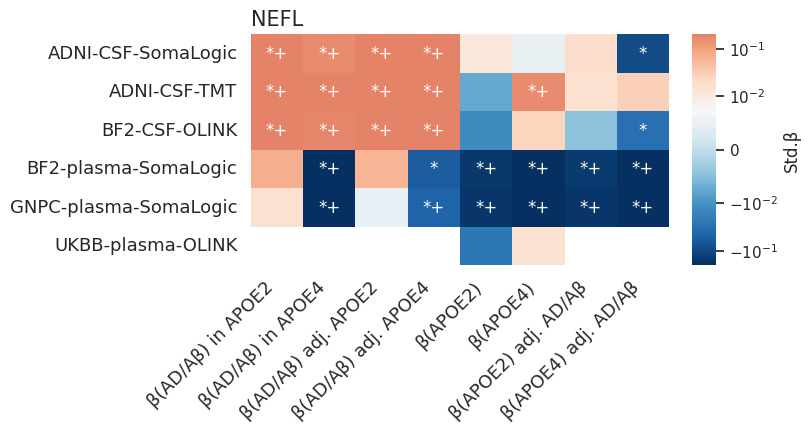

In [38]:
plt.figure(figsize=(6, 3))
ax = sns.heatmap(models.T, center=0, cmap='RdBu_r', norm=mcolors.SymLogNorm(linthresh=0.01, vmin=-0.2, vmax=0.2),
                 cbar_kws={'label': 'Std.β', "fraction": 0.05, "aspect": 10}, 
                 annot_kws={"fontsize": 12,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=annotation.T, fmt='')

plt.rcParams['font.size'] = 13

plt.gca().grid(False)
plt.xlabel('')
plt.ylabel('')
plt.title(f'{symbol}', fontsize=15, loc = 'left')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

changed = {'ADorAβ[APOE2]': 'β(AD/Aβ) in APOE2',
 'ADorAβ[APOE4]': 'β(AD/Aβ) in APOE4',
 'ADorAβ_adjAPOE[APOE2]': 'β(AD/Aβ) adj. APOE2',
 'ADorAβ_adjAPOE[APOE4]': 'β(AD/Aβ) adj. APOE4',
 'APOE[APOE2]': 'β(APOE2)',
 'APOE[APOE4]': 'β(APOE4)',
 'APOE_adjADorAβ[APOE2]': 'β(APOE2) adj. AD/Aβ',
 'APOE_adjADorAβ[APOE4]': 'β(APOE4) adj. AD/Aβ'}

xticks = ax.yaxis.get_major_ticks()
ax.set_xticklabels([changed[label.get_text()] for label in ax.get_xticklabels()])

plt.xticks(rotation=45, ha='right', va='top')
plt.yticks(rotation=0)

plt.show()

ax.figure.savefig(f"../Figs/other/{symbol}_acrossDatasets.svg", format='svg', dpi=600, bbox_inches='tight')

In [ ]:
export['stats for'] = export['model'].apply(lambda x: changed[x])
export['dataset'] = export['dataset_plusID'].apply(lambda x: x.split('[')[0])
export['id'] = export['id'].apply(lambda x: 'Plasma_NEFL_NPX' if x == 'CSF_NEFL_NPX' else x)
export_nongnpc = export[export['dataset'] != 'GNPC-plasma-SomaLogic']
export_gnpc = export[export['dataset'] == 'GNPC-plasma-SomaLogic']

def make_description(key):
    return {
        'β(AD/Aβ) in APOE2': f'{key} effect on NEFL in APOE2 analysis',
        'β(AD/Aβ) in APOE4': f'{key} effect on NEFL in APOE4 analysis',
        'β(AD/Aβ) adj. APOE2': f'{key} effect on NEFL with adjustment for APOE2',
        'β(AD/Aβ) adj. APOE4': f'{key} effect on NEFL with adjustment for APOE4',
        'β(APOE2)': 'APOE2 effect on NEFL',
        'β(APOE4)': 'APOE4 effect on NEFL',
        'β(APOE2) adj. AD/Aβ': f'APOE2 effect on NEFL with adjustment for {key}',
        'β(APOE4) adj. AD/Aβ': f'APOE4 effect on NEFL with adjustment for {key}'
    }

desc_ab = make_description('Aβ')
desc_ad = make_description('AD')

export_gnpc['Description'] = export_gnpc['stats for'].map(desc_ad)
export_nongnpc['Description'] = export_nongnpc['stats for'].map(desc_ab)

export = pd.concat([export_gnpc, export_nongnpc], join='inner')
export.sort_values(by=['dataset', 'stats for'], inplace=True)
export.drop(columns=['model', 'dataset_plusID']).to_excel('../SourceData/NEFL_across_datasets.xlsx', index=False)

# Summarize all mediators

In [39]:
validated = Counter([x.split('__')[0] for x in bf2soma_e4_ab.path1_proteins] + [x.split('__')[0] for x in adni_e4_ab.path1_proteins] + [x.split('__')[0] for x in bf2olink_e4_ab.path1_proteins] + [x.split('__')[0] for x in gnpc_e4_ad.path1_proteins] + [x.split('__')[0] for x in bf2soma_e4_ad.path1_proteins])
validated = [k for k,v in validated.items() if v > 1 ]
print(validated)

['TBCA', 'S100A13', 'BCDIN3D', 'CTF1', 'SPC25', 'HBQ1', 'LRRN1', 'ARL2']


In [40]:
set(validated) - set(bf2olink_e4_ab.apoe_result.data['symbol'].tolist())

{'ARL2', 'BCDIN3D', 'CTF1', 'HBQ1', 'SPC25'}

In [41]:
validated = Counter([x.split('__')[0] for x in bf2soma_e2_ab.path1_proteins] + [x.split('__')[0] for x in adni_e2_ab.path1_proteins] + [x.split('__')[0] for x in bf2olink_e2_ab.path1_proteins] + [x.split('__')[0] for x in gnpc_e2_ad.path1_proteins] + [x.split('__')[0] for x in bf2soma_e2_ad.path1_proteins])
validated = [k for k,v in validated.items() if v > 1 ]
validated

['SNAP23', 'APOB', 'WARS2', 'PCLAF']

In [42]:
set(validated) - set(bf2olink_e4_ab.apoe_result.data['symbol'].tolist())

{'APOB', 'PCLAF', 'WARS2'}

In [43]:
abeta_apoe4mediators = list(set([x.split('__')[0] for x in bf2soma_e4_ab.path1_proteins | adni_e4_ab.path1_proteins | bf2olink_e4_ab.path1_proteins]))# | adni_e4_ab.path1_proteins | bf2olink_path1_proteins
abeta_apoe2mediators = list(set([x.split('__')[0] for x in bf2soma_e2_ab.path1_proteins | adni_e2_ab.path1_proteins | bf2olink_e2_ab.path1_proteins]))
ad_apoe4mediators = list(set([x.split('__')[0] for x in gnpc_e4_ad.path1_proteins | bf2soma_e4_ad.path1_proteins | bf2olink_e4_ad.path1_proteins]))
ad_apoe2mediators = list(set([x.split('__')[0] for x in gnpc_e2_ad.path1_proteins | bf2soma_e2_ad.path1_proteins | bf2olink_e2_ad.path1_proteins]))
all = abeta_apoe4mediators + abeta_apoe2mediators + ad_apoe4mediators + ad_apoe2mediators

In [44]:
len(ad_apoe4mediators)

25

In [45]:
pd.DataFrame({'abeta_apoe4mediators': abeta_apoe4mediators + [np.nan] * (len(all)-len(abeta_apoe4mediators)),
              'abeta_apoe2mediators': abeta_apoe2mediators + [np.nan] * (len(all)-len(abeta_apoe2mediators)),
              'ad_apoe4mediators': ad_apoe4mediators + [np.nan] * (len(all)-len(ad_apoe4mediators)),
              'ad_apoe2mediators': ad_apoe2mediators + [np.nan] * (len(all)-len(ad_apoe2mediators))}).to_csv('../ref/mediators.csv', index=False)

# Heatmap of associations between APOE-related proteins and later AD-phenotypes

In [46]:
mark = 'Aβ+'

if mark == 'Aβ-':
    dat = pd.read_excel('../data/BF2SomaLogic/Rresults/ad_markers_associations_Abneg.xlsx')
else:
    dat = pd.read_excel('../data/BF2SomaLogic/Rresults/ad_markers_associations_Abpos.xlsx')

In [47]:
dat['sig_taupet'] = dat.apply(lambda row: '*+' if (row['p_taupet']<0.05) & (row['p_fdr_taupet']<0.05) else('*' if row['p_taupet']<0.05 else ''), axis=1)
dat['sig_Abpet'] = dat.apply(lambda row: '*+' if (row['p_Abpet']<0.05) & (row['p_fdr_Abpet']<0.05) else('*' if row['p_Abpet']<0.05 else ''), axis=1)
dat['sig_ADsign'] = dat.apply(lambda row: '*+' if (row['p_ADsign']<0.05) & (row['p_fdr_ADsign']<0.05) else('*' if row['p_ADsign']<0.05 else ''), axis=1)
dat['sig_mmse'] = dat.apply(lambda row: '*+' if (row['p_mmse']<0.05) & (row['p_fdr_mmse']<0.05) else('*' if row['p_mmse']<0.05 else ''), axis=1)
dat['sig_mpacc'] = dat.apply(lambda row: '*+' if (row['p_mpacc']<0.05) & (row['p_fdr_mpacc']<0.05) else('*' if row['p_mpacc']<0.05 else ''), axis=1)

In [48]:
dat['sig'] = dat.apply(lambda row: 'sig' if row['p_fdr_taupet'] <0.05 or row['p_fdr_Abpet'] <0.05 or row['p_fdr_ADsign'] <0.05 or row['p_fdr_mmse'] <0.05 or row['p_fdr_mpacc'] <0.05 else 'not', axis=1)
kept = dat[dat['sig'] == 'sig']
toheatmap = kept[['ref_name'] + [x for x in kept.columns if x[:7]=='StdBeta']]
toheatmap.set_index('ref_name', inplace=True)
annotation = kept[['ref_name'] + [x for x in kept.columns if x[:4]=='sig_']]
annotation.set_index('ref_name', inplace=True)

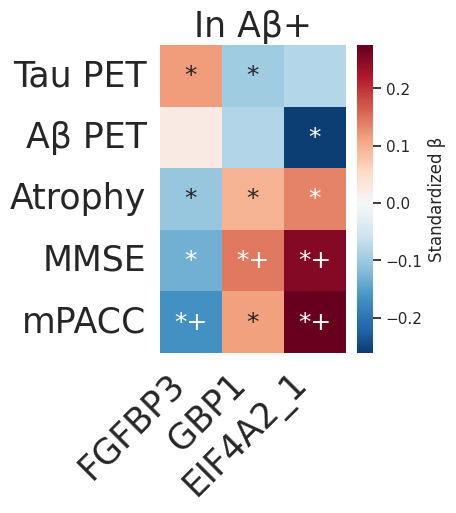

In [50]:
plt.figure(figsize=(1*len(toheatmap.index), 4))
ax = sns.heatmap(toheatmap.T, center=0, cmap='RdBu_r', cbar_kws={'label': 'Standardized β'}, 
                 annot_kws={"fontsize": 18,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=annotation.T, fmt='')

plt.rcParams['font.size'] = 25

plt.gca().grid(False)
plt.xlabel('')
plt.ylabel('')
plt.title(f'In {mark}', fontsize=25, loc = 'center')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

xticks = ax.xaxis.get_major_ticks()
labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticklabels([bf2soma_e4_ab.id2label[x] for x in labels])
for tick, label in zip(xticks, labels):
    if label in bf2soma_e4_ab.path1_proteins:
        tick.label1.set_color('#DC0000B2')
    elif label in bf2soma_e2_ab.path1_proteins:
        tick.label1.set_color('green')
ax.set_yticklabels(['Tau PET', 'Aβ PET', 'Atrophy', 'MMSE', 'mPACC'])
plt.xticks(rotation=45, ha='right', va='top')
plt.yticks(rotation=0)

plt.show()
ax.figure.savefig(f"../Figs/BF2SomaLogic/heatmap_ADmarkers_in_{mark}.svg", format='svg', dpi=300, bbox_inches='tight')

# Merge all results

#### These data were later integrated into the source data.

In [51]:
ukbb_merged = pd.merge(ukbb_e4.apoe_result.data[['Protein_id', 'coef','standardized_beta', 'se', 'resid', 'p', 'p_adjusted']],
                  ukbb_e2.apoe_result.data[['Protein_id', 'coef','standardized_beta', 'se', 'resid', 'p', 'p_adjusted']], on='Protein_id', how='outer')
ukbb_merged['Protein_id'] = ukbb_merged['Protein_id'].apply(lambda x: f'Plasma_{'_'.join(x.split('_')[1:])}')
tmp = pd.DataFrame([['Protein_id', 'APOE4 associated proteins', '', '', '', '', '','APOE2 associated proteins', '', '', '', '', ''],
                            ['Protein_id'] + ['coef', 'std.beta','se', 'resid', 'p', 'p_adjusted'] * 2], columns=ukbb_merged.columns.tolist())
ukbb_merged = pd.concat([tmp, ukbb_merged], ignore_index=True)

In [ ]:
sheets_to_write = [
    ('GNPC_APOE2_AD_Fig2', gnpc_e2_ad),
    ('GNPC_APOE4_AD_Fig3', gnpc_e4_ad),
    ('BF2soma_APOE4_AD_Fig5a', bf2soma_e4_ad),
    ('BF2soma_APOE2_AD', bf2soma_e2_ad),
    ('BF2soma_APOE4_Aβ_Fig5b', bf2soma_e4_ab),
    ('BF2soma_APOE2_Aβ', bf2soma_e2_ab),
    ('ADNI_APOE4_Aβ_Fig6ab', adni_e4_ab),
    ('ADNI_APOE2_Aβ', adni_e2_ab),
    ('ADNI_TMTMS_APOE4_Aβ', adnitmt_e4_ab),
    ('ADNI_TMTMS_APOE2_Aβ', adnitmt_e2_ab),
    ('BF2OLINK_APOE4_AD', bf2olink_e4_ad),
    ('BF2OLINK_APOE2_AD', bf2olink_e2_ad),
    ('BF2OLINK_APOE4_Aβ_SupFig9', bf2olink_e4_ab),
    ('BF2OLINK_APOE2_Aβ_SupFig9', bf2olink_e2_ab),
    ('ROSMAP_APOE4', rosmap_e4),
    ('ROSMAP_APOE2', rosmap_e2)
]

with pd.ExcelWriter('../Supplement/Table_2_model_results.xlsx', engine='xlsxwriter', mode='w') as writer:
    for sheet_name, model in sheets_to_write:
        df = model._extract_sup_dfs()
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name, index=False, header=None)
        else:
            print(sheet_name)
    
    ukbb_merged.to_excel(writer, sheet_name='UKBB', index=False, header=None)

In [ ]:
sheets_to_write = [
    ('BF2soma_APOE4_Aβ_PC1-5', bf2soma_e4_pc10),
    ('BF2soma_APOE2_Aβ_PC1-5', bf2soma_e2_pc10),
    ('BF2soma_APOE4_Aβ_wml', bf2soma_e4_wml),
    ('BF2soma_APOE2_Aβ_wml', bf2soma_e2_wml),
    ('BF2soma_APOE4_Aβ_medication', bf2soma_e4_drug),
    ('BF2soma_APOE2_Aβ_medication', bf2soma_e2_drug),
    ('BF2soma_APOE4_CSFAβ_continuous', bf2soma_e4_AbRatio),
    ('BF2soma_APOE2_CSFAβ_continuous', bf2soma_e2_AbRatio),
    ('BF2soma_APOE4_AβPET_continuous', bf2soma_e4_AbPET),
    ('BF2soma_APOE2_AβPET_continuous', bf2soma_e2_AbPET),
]

with pd.ExcelWriter('../Supplement/Table_8_sensitivity.xlsx', engine='xlsxwriter', mode='w') as writer:
    for sheet_name, model in sheets_to_write:
        df = model._extract_sup_dfs()
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name, index=False, header=None)
        else:
            print(sheet_name)

In [ ]:
sheets_to_write = [
    ('ROSMAP-APOE4', rosmap_e4),
    ('ROSMAP-APOE2', rosmap_e2)
]

with pd.ExcelWriter('../Supplement/Table_4_rosmap.xlsx', engine='xlsxwriter', mode='w') as writer:
    for sheet_name, model in sheets_to_write:
        df = model._extract_sup_dfs()
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name, index=False, header=None)
        else:
            print(sheet_name)

# To cell type enrichment

In [ ]:
apoe = 'APOE2'
if apoe == 'APOE4':
    out = '../celltype/data/early_apoe4.xlsx'
    Results = copy.deepcopy(gnpc_e4_ad)
else:
    out = '../celltype/data/early_apoe2.xlsx'
    Results = copy.deepcopy(gnpc_e2_ad)

ref2uni = dict(zip(Results.apoe_result.data['ref_name'].tolist(), Results.apoe_result.data['UniProt'].tolist()))
ref2effect = dict(zip(Results.apoe_result.data['ref_name'].tolist(), Results.apoe_result.data['standardized_beta'].tolist()))
ref2label = dict(zip(Results.apoe_result.data['ref_name'].tolist(), Results.apoe_result.data['label'].tolist()))
ref2symbol = dict(zip(Results.apoe_result.data['ref_name'].tolist(), Results.apoe_result.data['symbol'].tolist()))

bg = set(Results.apoe_result.data[~Results.apoe_result.data['symbol'].isna()]['ref_name'].tolist())
genesets = pd.DataFrame({'bg_apt': list(bg)})
genesets['genesymbol'] = genesets['bg_apt'].apply(lambda x: ref2symbol[x] if x in ref2symbol.keys() else np.nan)
genesets['uni'] = genesets['bg_apt'].apply(lambda x: ref2uni[x] if x in ref2uni.keys() else np.nan)
genesets['label'] = genesets['bg_apt'].apply(lambda x: ref2label[x] if x in ref2label.keys() else np.nan)

genesets[f'early'] = genesets['bg_apt'].apply(lambda x: x if x in (Results.apoe_result.sig & Results.neg_allage.sig) else np.nan)
genesets[f'early_uni'] = genesets[f'early'].apply(lambda x: ref2uni[x] if x in ref2uni.keys() else np.nan)
genesets[f'early_label'] = genesets[f'early'].apply(lambda x: ref2label[x] if x in ref2label.keys() else np.nan)
genesets[f'early_genesymbol'] = genesets[f'early'].apply(lambda x: ref2symbol[x] if x in ref2symbol.keys() else np.nan)
genesets[f'early Regulation'] = genesets[f'early'].apply(lambda x: ref2effect[x] if x in ref2effect.keys() else np.nan)
genesets[f'early Regulation'] = genesets[f'early Regulation'].apply(lambda x: 'up' if x > 0 else 'down' if x <= 0 else np.nan)

In [55]:
apoe = 'APOE2'
if apoe == 'APOE4':
    out = '../data/GNPC/gnpc_apoe4associated_357apt_0828_previousFormat.xlsx'
    Results = copy.deepcopy(gnpc_e4_ad)
else:
    out = '../data/GNPC/gnpc_apoe2associated_192apt_0828_previousFormat.xlsx'
    Results = copy.deepcopy(gnpc_e2_ad)

apoe2protein = Results.apoe_result.data

bg = set(apoe2protein[~apoe2protein['symbol'].isna()]['ref_name'].tolist())
ref2uni = dict(zip(apoe2protein['ref_name'].tolist(), apoe2protein['UniProt'].tolist()))
ref2effect = dict(zip(apoe2protein['ref_name'].tolist(), apoe2protein['standardized_beta'].tolist()))
ref2label = dict(zip(apoe2protein['ref_name'].tolist(), apoe2protein['label'].tolist()))
ref2symbol = dict(zip(apoe2protein['ref_name'].tolist(), apoe2protein['symbol'].tolist()))

genesets = pd.DataFrame({'bg_genesymbol':[ref2symbol[x] for x in list(bg)],
                        'bg_uni':[ref2uni[x] for x in list(bg)],
                        'bg_label':[ref2label[x] for x in list(bg)],
                        f'{Results.apoe_identifier}':list(Results.apoe_result.sig) + ['']*(len(bg)-len(Results.apoe_result.sig))})
genesets['group'] = genesets[f'{Results.apoe_identifier}'].apply(lambda x: 'mediator-proteins' if x in Results.path1_proteins 
                                          else('AD-mediated proteins' if x in Results.path2_proteins 
                                               else(f'{Results.apoe_identifier}-specific' if x in Results.apoe_solo 
                                                    else('undivided' if x in Results.apoe_result.sig else np.nan))))

genesets[f'{Results.apoe_identifier}_uni'] = genesets[f'{Results.apoe_identifier}'].apply(lambda x: ref2uni[x] if x in ref2uni.keys() else np.nan)
genesets[f'{Results.apoe_identifier}_label'] = genesets[f'{Results.apoe_identifier}'].apply(lambda x: ref2label[x] if x in ref2label.keys() else np.nan)
genesets[f'{Results.apoe_identifier}_genesymbol'] = genesets[f'{Results.apoe_identifier}'].apply(lambda x: ref2symbol[x] if x in ref2symbol.keys() else np.nan)
genesets['Regulation'] = genesets[f'{Results.apoe_identifier}'].apply(lambda x: ref2effect[x] if x in ref2effect.keys() else np.nan)
genesets['Regulation'] = genesets['Regulation'].apply(lambda x: 'up' if x > 0 else 'down' if x <= 0 else np.nan)
genesets.to_excel(f'{out}', index=False)
pd.crosstab(genesets["group"], genesets["Regulation"])

Regulation,down,up
group,,
AD-mediated proteins,17,4
APOE2-specific,70,28
mediator-proteins,42,12
undivided,12,7


## Different direction of APOE4 and APOE2 associated proteins

In [34]:
gnpc_e2_ad.path2_proteins & gnpc_e4_ad.path1_proteins

{'SNRPF__seq.5494.52'}

In [ ]:
# Downstream protein is driven by AD
gnpc_e2_ad.pathology_result.data[gnpc_e2_ad.pathology_result.data['ref_name'].isin(gnpc_e2_ad.path2_proteins & gnpc_e4_ad.path1_proteins)]

,apt_name,Protein_id,coef,standardized_beta,se,t,p,R_squared,R_squared_adj,resid,CI95_lower,CI95_upper,p_adjusted,UniProt,EntrezGeneSymbol,symbol,ref_name,label,significance
5569,seq.5494.52,seq_5494_52,0.05134,0.05134,0.014978,3.427665,0.000621,0.044178,0.039853,1989,0.021965,0.080714,0.002703,P62306,SNRPF,SNRPF,SNRPF__seq.5494.52,SNRPF,*+


In [60]:
# Upstream protein is driven by APOE
gnpc_e4_ad.neg_allage.data[gnpc_e4_ad.neg_allage.data['ref_name'].isin(gnpc_e2_ad.path2_proteins & gnpc_e4_ad.path1_proteins)]

,apt_name,Protein_id,coef,standardized_beta,se,t,p,R_squared,R_squared_adj,resid,CI95_lower,CI95_upper,p_adjusted,UniProt,EntrezGeneSymbol,symbol,ref_name,label,significance
5569,seq.5494.52,seq_5494_52,-0.152747,-0.152747,0.011618,-13.147939,1.039388e-37,0.123242,0.120211,1736,-0.175533,-0.129962,3.985234e-35,P62306,SNRPF,SNRPF,SNRPF__seq.5494.52,SNRPF,*+


In [40]:
len(gnpc_e2_ad.path1_proteins & gnpc_e4_ad.path2_proteins)

26

In [68]:
merged = pd.merge(gnpc_e4_ad.pathology_adj_result.data[['ref_name', 'symbol', 'standardized_beta', 'p_adjusted']], 
                  gnpc_e2_ad.neg_allage.data[['ref_name', 'symbol', 'standardized_beta', 'p_adjusted']], 
                  on=['ref_name', 'symbol'], suffixes=('_adine4', '_e2incu'))
merged['direction'] = merged.apply(lambda row: 'same' if row['standardized_beta_adine4'] * row['standardized_beta_e2incu'] > 0 else 'opposite', axis=1)
merged = merged[merged['ref_name'].isin(gnpc_e2_ad.path1_proteins & gnpc_e4_ad.path2_proteins)]

print('Proteins downregulated by APOE2 in CU and upregulated by AD in APOE4 carriers:')
for x in merged[merged['direction']=='opposite']['symbol'].tolist():
    if merged[merged['symbol']==x]['standardized_beta_e2incu'].values[0] < 0:
        print(x)

print('Proteins upregulated by APOE2 in CU and downregulated by AD in APOE4 carriers:')
for x in merged[merged['direction']=='opposite']['symbol'].tolist():
    if merged[merged['symbol']==x]['standardized_beta_e2incu'].values[0] > 0:
        print(x)

Proteins downregulated by APOE2 in CU and upregulated by AD in APOE4 carriers:
KRT19
STXBP6
RNGTT
SNAP23
RASSF2
HES5
KCTD2
ACOT12
APOB
MAPK8
PLA2G7
TMCC3
PSG5
Proteins upregulated by APOE2 in CU and downregulated by AD in APOE4 carriers:
STK10


In [63]:
for x in merged[merged['direction']=='same']['symbol'].tolist():
    if merged[merged['symbol']==x]['standardized_beta_e2incu'].values[0] < 0:
        print(x)

HSPA1L
RHOG
TRADD
PPM1G
RPN2
PSMB10
KRT14
OLAH
CAPN13
BMPR2


In [ ]:
a = list(set([bf2soma_e4_ad.id2symbol[x] for x in bf2soma_e4_ad.neg_allage.sig & bf2soma_e4_ad.apoe_result.sig]))
b = list(set([bf2soma_e2_ad.id2symbol[x] for x in bf2soma_e2_ad.neg_allage.sig & bf2soma_e2_ad.apoe_result.sig]))

pd.DataFrame({'bg':list(set(bf2soma_e4_ad.apoe_result.data['symbol'].tolist())),
                'apoe4_early': a + ['']*(len(set(bf2soma_e4_ad.apoe_result.data['symbol'].tolist())) - len(a)),
                'apoe2_early': b + ['']*(len(set(bf2soma_e4_ad.apoe_result.data['symbol'].tolist())) - len(b)),
              }).to_csv('../celltype/data/bf2soma_early.csv', index=False)

In [64]:
a = [x for x in merged[merged['direction']=='opposite']['symbol'].tolist() if merged[merged['symbol']==x]['standardized_beta_e2incu'].values[0] < 0]
b = [x for x in merged[merged['direction']=='same']['symbol'].tolist() if merged[merged['symbol']==x]['standardized_beta_e2incu'].values[0] < 0]
c = list(set([ref2symbol[x] for x in gnpc_e4_ad.neg_allage.sig & gnpc_e2_ad.neg_allage.sig]))
pd.DataFrame({'bg':list(set(gnpc_e4_ad.pathology_result.data['symbol'].tolist())),
              'apoe2upstream_downinapoe2_apoe4downstream_upinad':list(set(a)) + ['']*(len(set(gnpc_e4_ad.pathology_result.data['symbol'].tolist())) - len(set(a))),
              'apoe2upstream_downinapoe2_apoe4downstream_downinad':list(set(b)) + ['']*(len(set(gnpc_e4_ad.pathology_result.data['symbol'].tolist())) - len(set(b))),
                'bothapoe2andapoe4early': c + ['']*(len(set(gnpc_e4_ad.pathology_result.data['symbol'].tolist())) - len(c)),
              }).to_csv('../celltype/data/bidirectional.csv', index=False)

In [ ]:
apoe4 = list(set([adni_e4_ab.id2symbol[x] for x in (adni_e4_ab.neg_allage.sig & adni_e4_ab.apoe_result.sig)]))
apoe2 = list(set([adni_e2_ab.id2symbol[x] for x in (adni_e2_ab.neg_allage.sig & adni_e2_ab.apoe_result.sig)]))

pd.DataFrame({'bg':list(set(adni_e4_ab.apoe_result.data['symbol'].tolist())),
                'adni_abneg_apoe4': apoe4 + ['']*(len(set(adni_e4_ab.apoe_result.data['symbol'].tolist())) - len(apoe4)),
                'adni_abneg_apoe2': apoe2 + ['']*(len(set(adni_e4_ab.apoe_result.data['symbol'].tolist())) - len(apoe2)),
              }).to_csv('../celltype/data/adni.csv', index=False)

In [ ]:
apoe4 = list(set([bf2soma_e4_ab.id2symbol[x] for x in (bf2soma_e4_ab.neg_allage.sig & bf2soma_e4_ab.apoe_result.sig)]))
apoe2 = list(set([bf2soma_e2_ab.id2symbol[x] for x in (bf2soma_e2_ab.neg_allage.sig & bf2soma_e2_ab.apoe_result.sig)]))
early = list(set([bf2soma_e2_ab.id2symbol[x] for x in bf2soma_e4_ab.neg_allage.sig & bf2soma_e2_ab.neg_allage.sig]))
pd.DataFrame({'bg':list(set(bf2soma_e4_ab.apoe_result.data['symbol'].tolist())),
                'bf2soma_abneg_apoe4': apoe4 + ['']*(len(set(bf2soma_e4_ab.apoe_result.data['symbol'].tolist())) - len(apoe4)),
                'bf2soma_abneg_apoe2': apoe2 + ['']*(len(set(bf2soma_e4_ab.apoe_result.data['symbol'].tolist())) - len(apoe2)),
                'bf2soma_both_early': early + ['']*(len(set(bf2soma_e4_ab.apoe_result.data['symbol'].tolist())) - len(early)),
              }).to_csv('../celltype/data/bf2soma.csv', index=False)

# AD-specific

In [ ]:
len(gnpc_e4_ad.pathology_solo & gnpc_e2_ad.pathology_solo)

2396

In [62]:
set(['OMG', 'SMOC1', 'GPD1', 'POSTN']) - set([Results1.id2symbol[x] for x in Results1.pathology_solo & Results2.pathology_solo])

set()

In [66]:
a = Results1.apoe_result.data[Results1.apoe_result.data['symbol'].isin(['OMG', 'SMOC1', 'GPD1', 'POSTN'])]['ref_name'].tolist()

Counter({'same': 7, 'opposite': 5})


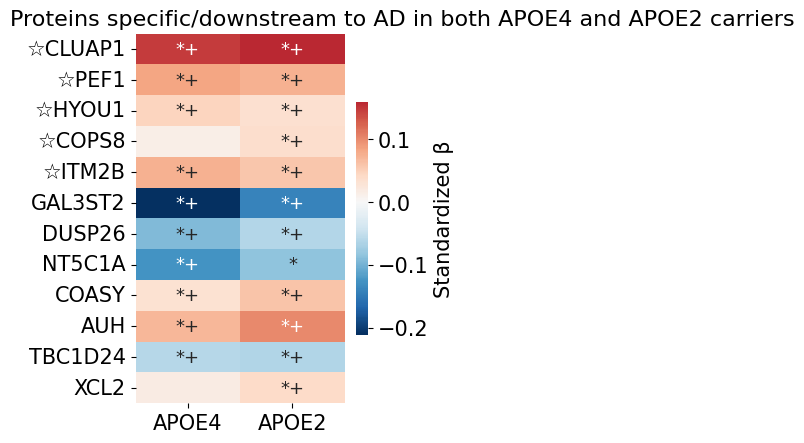

In [76]:
Results1 = copy.deepcopy(gnpc_e4_ad)
Results2 = copy.deepcopy(gnpc_e2_ad)

lists = Results1.path2_proteins & Results2.path2_proteins
models, annotations, ref2bold, ref2type = utils.prepare_heatmap_inputs(lists, Results1, Results2, 0)

print(Counter(ref2bold.values()))

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.figure(figsize=(3, len(models)*0.4))
ax = sns.heatmap(models[[f'APOE4_β4',f'APOE2_β4']], center=0, cmap='RdBu_r', 
                 cbar_kws={'label': 'Standardized β', "fraction": 0.05, "aspect": 20}, 
                 annot_kws={"fontsize": 13,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=annotations[[f'APOE4_p4',f'APOE2_p4']], fmt='')

plt.rcParams['font.size'] = 15

plt.gca().grid(False)
plt.xlabel('')
plt.ylabel('')
plt.title(f'Proteins specific/downstream to AD in both APOE4 and APOE2 carriers', fontsize=16,loc = 'left', x=-0.6)#
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

xticks = ax.yaxis.get_major_ticks()
labels = [label.get_text() for label in ax.get_yticklabels()]

for tick, label in zip(xticks, labels):
    if label in Results1.path1_proteins & Results2.path1_proteins:
        tick.label1.set_color('purple')
    elif ref2type[label] == 'apoe4 mediator':
        tick.label1.set_color('#DC0000B2')
    elif ref2type[label] == 'apoe2 mediator':
        tick.label1.set_color('#2166ACFF')
    else:
        tick.label1.set_color('black')

ax.set_yticklabels([f'☆{Results1.id2label[x]}' if ref2bold[x] == 'opposite' else Results1.id2label[x] for x in labels])

ax.set_xticklabels(['APOE4','APOE2'])

#plt.xticks(rotation=45, ha='right', va='top')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()
ax.figure.savefig(f"../Figs/{Results1.fig_folder}/early_dys_in_both.svg", format='svg', dpi=600, bbox_inches='tight')

#Source data
#Source data
tmp1 = Results1.neg_allage.data[['ref_name', 'label', 'standardized_beta','p', 'p_adjusted', 'significance']]
tmp1 = pd.merge(tmp1, 
                Results2.neg_allage.data[['ref_name', 'label', 'standardized_beta','p', 'p_adjusted', 'significance']], 
                how='inner', 
                on=['ref_name', 'label'],
                suffixes=('_APOE4', '_APOE2'))

#
tmp1 = tmp1[tmp1['ref_name'].isin(models.index.tolist())]
tmp1.to_excel(f'../SourceData/{Results1.dataset}_early_dys.xlsx')

# Heatmap of correlation of R² or β

In [88]:
identifier = 'standardized_beta' 
apoe = 'APOE4'
analysis = 'sensitivity'

In [89]:
if identifier == 'R2':
    col = 'R_squared_adj'
    title_ = f'Adjusted R2 ({apoe})'
else:
    col = 'standardized_beta'
    title_ = f'Std.β ({apoe})'

figout = f"../Figs/other/{analysis}_{identifier}_{apoe}.svg"

In [90]:
lm_cols = {
    "beta": col,
}

dfs = []
key = None

if analysis == "sensitivity":
    key = "ref_name"
    if apoe == "APOE2":
        dfs.append(utils.pick_and_rename_multi(gnpc_e2_ad.apoe_result.data, key, lm_cols, "GNPC-AD"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e2_ad.apoe_result.data, key, lm_cols, "BF2-AD"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e2_ab.apoe_result.data, key, lm_cols, "BF2-Aβ"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e2_pc10.apoe_result.data, key, lm_cols, "BF2-Aβ-ancestry"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e2_drug.apoe_result.data, key, lm_cols, "BF2-Aβ-medication"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e2_wml.apoe_result.data, key, lm_cols, "BF2-Aβ-wml"))
    else:
        dfs.append(utils.pick_and_rename_multi(gnpc_e4_ad.apoe_result.data, key, lm_cols, "GNPC-AD"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e4_ad.apoe_result.data, key, lm_cols, "BF2-AD"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e4_ab.apoe_result.data, key, lm_cols, "BF2-Aβ"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e4_pc10.apoe_result.data, key, lm_cols, "BF2-Aβ-ancestry"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e4_drug.apoe_result.data, key, lm_cols, "BF2-Aβ-medication"))
        dfs.append(utils.pick_and_rename_multi(bf2soma_e4_wml.apoe_result.data, key, lm_cols, "BF2-Aβ-wml"))

elif analysis == "cohorts":
    if 'symbol' not in ukbb_e4.apoe_result.data.columns.tolist():
        ukbb_e4.apoe_result.data["symbol"] = ukbb_e4.apoe_result.data["Protein_id"].apply(lambda x: x.split("_")[1])
    if 'symbol' not in ukbb_e2.apoe_result.data.columns.tolist():
        ukbb_e2.apoe_result.data["symbol"] = ukbb_e2.apoe_result.data["Protein_id"].apply(lambda x: x.split("_")[1])

    key = "symbol"

    if apoe == "APOE4":
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(gnpc_e4_ad.apoe_result.data), key, lm_cols, "GNPC-plasma-Somalogic"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(bf2soma_e4_ab.apoe_result.data), key, lm_cols, "BF2-plasma-Somalogic"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(adni_e4_ab.apoe_result.data), key, lm_cols, "ADNI-CSF-Somalogic"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(adnitmt_e4_ab.apoe_result.data), key, lm_cols, "ADNI-CSF-TMT"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(bf2olink_e4_ab.apoe_result.data), key, lm_cols, "BF2-CSF-OLINK"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(ukbb_e4.apoe_result.data), key, lm_cols, "UKBB-plasma-OLINK"))
    else:
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(gnpc_e2_ad.apoe_result.data), key, lm_cols, "GNPC-plasma-Somalogic"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(bf2soma_e2_ab.apoe_result.data), key, lm_cols, "BF2-plasma-Somalogic"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(adni_e2_ab.apoe_result.data), key, lm_cols, "ADNI-CSF-Somalogic"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(adnitmt_e2_ab.apoe_result.data), key, lm_cols, "ADNI-CSF-TMT"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(bf2olink_e2_ab.apoe_result.data), key, lm_cols, "BF2-CSF-OLINK"))
        dfs.append(utils.pick_and_rename_multi(utils.best_per_symbol(ukbb_e2.apoe_result.data), key, lm_cols, "UKBB-plasma-OLINK"))

dfs = [d for d in dfs if d is not None]

merged = reduce(lambda left, right: pd.merge(left, right, on=key, how="outer"), dfs)
merged.set_index(key, inplace=True)
merged.columns = [x.split('_')[0] for x in merged.columns.tolist()]
corr_matrix = merged.corr(method="spearman")


In [91]:
p_matrix = pd.DataFrame(np.nan, index=merged.columns, columns=merged.columns)
p_values = []
pairs = []

for col1, col2 in combinations(merged.columns, 2):
    mask = merged[[col1, col2]].notna().all(axis=1)
    if mask.sum() >= 2:
        _, p = stats.spearmanr(merged.loc[mask, col1], merged.loc[mask, col2])
        p_values.append(p)
        pairs.append((col1, col2))

rejected, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')

for (col1, col2), p_corr in zip(pairs, pvals_corrected):
    p_matrix.loc[col1, col2] = p_corr
    p_matrix.loc[col2, col1] = p_corr

annotations = p_matrix.map(lambda x: '*' if x < 0.05 else '')

cor = round(corr_matrix, 2)
result = cor.astype(str) + annotations.astype(str)


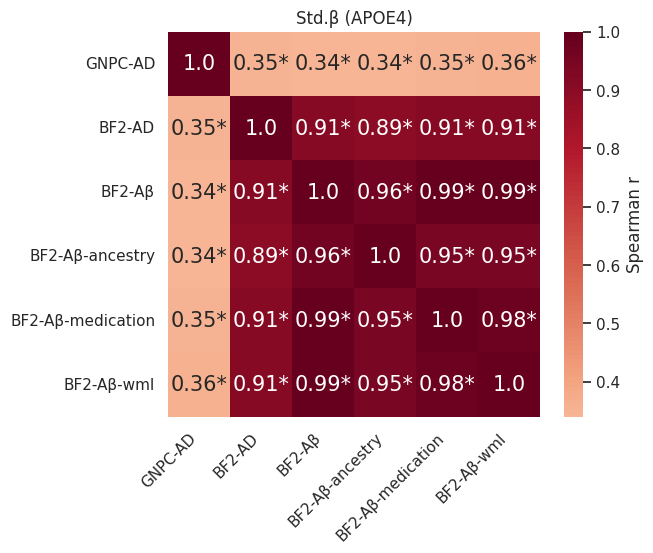

In [92]:
plt.rcParams['font.size'] = 20
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.heatmap(cor, center=0, cmap='RdBu_r', cbar_kws={'label': 'Spearman r'}, 
                 annot_kws={"fontsize": 15,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=result, fmt='')
plt.title(title_)
plt.xticks(rotation=45, ha='right', va='top')

ax.figure.savefig(figout, format='svg', dpi=600, bbox_inches='tight')

# Heatmap: Most mediators identified in SomaLogic were not availabel in OLINK and TMT-MS

In [93]:
apoe = 'APOE4'

In [97]:
e4_mediators = set([x.split('__')[0] for x in bf2soma_e4_ab.path1_proteins] + [x.split('__')[0] for x in adni_e4_ab.path1_proteins]  + [x.split('__')[0] for x in gnpc_e4_ad.path1_proteins])
len(e4_mediators)

40

In [98]:
e2_mediators = set([x.split('__')[0] for x in bf2soma_e2_ab.path1_proteins] + [x.split('__')[0] for x in adni_e2_ab.path1_proteins] + [x.split('__')[0] for x in gnpc_e2_ad.path1_proteins])
len(e2_mediators)

54

In [99]:
set(e4_mediators | e2_mediators) - set(rosmap_e4.apoe_result.data['symbol'].tolist())

{'ACOT12',
 'APOB',
 'CDHR5',
 'IRF6',
 'KRT14',
 'MAGEA3',
 'MEOX2',
 'NEFL',
 'OASL',
 'OLAH',
 'PSG5',
 'RGS21',
 'SLC5A8',
 'SPON1',
 'TECTB'}

In [100]:
soma_mediators = pd.DataFrame({'APOE4_mediators': list(e4_mediators) + [np.nan]*(max(len(e4_mediators), len(e2_mediators)) - len(e4_mediators)),
                               'APOE2_mediators': list(e2_mediators) + [np.nan]*(max(len(e4_mediators), len(e2_mediators)) - len(e2_mediators))})
soma_mediators.to_csv('../ref/soma_mediators.csv', index=False)

In [102]:
proteins = e4_mediators if apoe == 'APOE4' else e2_mediators
figout = f"../Figs/other/sup_fig8{apoe}.svg"

In [103]:
key = "symbol"
lm_cols = {
    "beta": 'standardized_beta',
    "p": "p",
    "fdr": "p_adjusted",
    "sig": "significance"
}
dfs = []

# --- ensure UKBB symbol exists ---
for obj in [ukbb_e4, ukbb_e2]:
    d = obj.apoe_result.data.copy()
    d["symbol"] = d["Protein_id"].astype(str).apply(lambda x: x.split("_")[1] if "_" in x else np.nan)
    obj.apoe_result.data = d

if apoe == "APOE4":
    for apoe2protein in [gnpc_e4_ad, bf2soma_e4_ab, adni_e4_ab, adnitmt_e4_ab, bf2olink_e4_ab, ukbb_e4]:
        df0 = utils.best_per_symbol(apoe2protein.apoe_result.data, p_col=lm_cols["fdr"])
        dfs.append(utils.pick_and_rename_multi(
            df0,
            key,
            lm_cols,
            apoe2protein.dataset
        ))
else:
    for apoe2protein in [gnpc_e2_ad, bf2soma_e2_ab, adni_e2_ab, adnitmt_e2_ab, bf2olink_e2_ab, ukbb_e2]:
        df0 = utils.best_per_symbol(apoe2protein.apoe_result.data, p_col=lm_cols["fdr"])
        dfs.append(utils.pick_and_rename_multi(
            df0,
            key,
            lm_cols,
            apoe2protein.dataset
        ))

dfs = [d for d in dfs if d is not None and not d.empty]

merged = reduce(lambda left, right: pd.merge(left, right, on=key, how="outer"), dfs)
merged = merged.drop_duplicates(subset=[key]).set_index(key)



In [104]:
merged = merged[merged.index.isin(proteins)]

matrix = merged[[col for col in merged.columns if col.endswith('__beta')]].T
annotation = merged[[col for col in merged.columns if col.endswith('__sig')]].T
matrix.fillna(np.nan, inplace=True)
annotation.fillna('', inplace=True)

symbol,ARL2,ATE1,ATG7,BCDIN3D,BMP6,BOLA3,CDA,CDK5RAP3,COMTD1,CTF1,...,SPON1,ST8SIA1,TBCA,TCF12,TP53I11,UBL3,UCHL5,VPS29,WNT10B,ZW10
GNPC-plasma-SomaLogic__sig,*+,*+,,*+,*,,*+,*+,*+,*+,...,*,*+,*+,*+,*+,*+,,*+,*+,*+
BF2-plasma-SomaLogic__sig,*+,,,*+,*,,*+,*+,*+,*+,...,,*+,*+,*+,*+,*+,,*+,*+,*+
ADNI-CSF-SomaLogic__sig,*+,*+,*+,*+,*+,*+,,*+,*+,*+,...,*+,*+,*+,,*+,,*+,*+,*+,
ADNI-CSF-TMT__sig,,,,,,,,,,,...,*+,,*+,,,,,,,
BF2-CSF-OLINK__sig,,,,,,,,,,,...,*+,,*,,,,,,,
UKBB-plasma-OLINK__sig,,,,,,,,,,,...,,,,,,,,,,


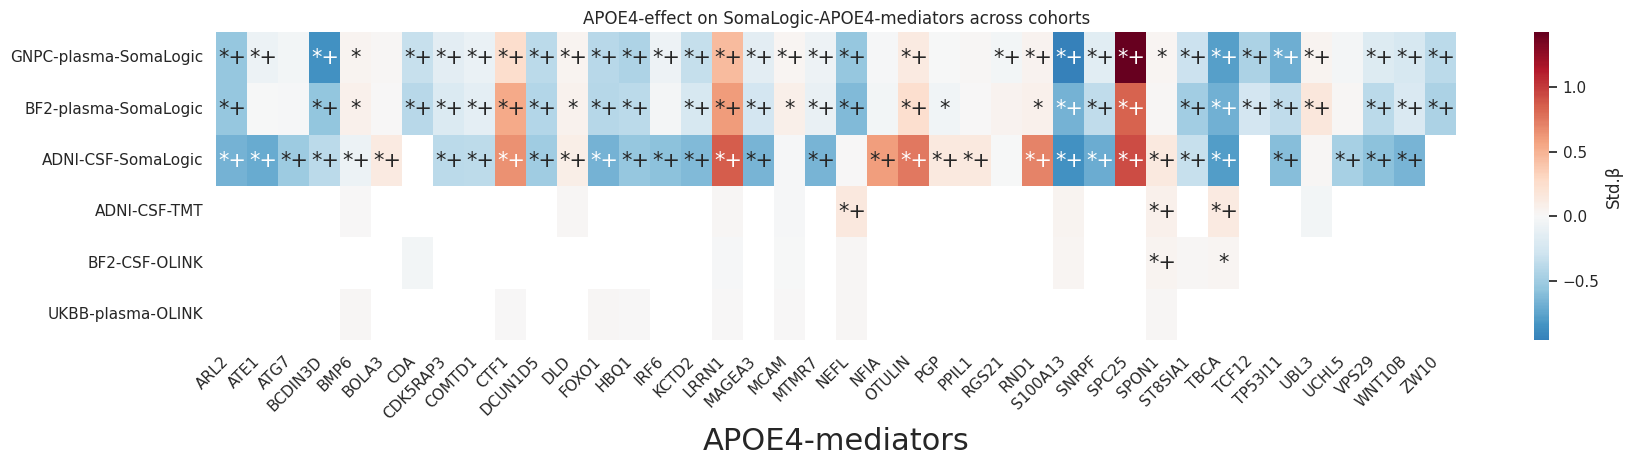

In [105]:
plt.rcParams['font.size'] = 20
fig, ax = plt.subplots(figsize=(0.6*len(matrix.columns) if len(matrix.columns) < 20 else 0.5*len(matrix.columns), 4))
ax = sns.heatmap(matrix, center=0, cmap='RdBu_r', cbar_kws={'label': 'Std.β'}, 
                 annot_kws={"fontsize": 15,"ha": "center", "va": "center"}, 
                 linewidths=0, annot=annotation, fmt='')
plt.title(f'{apoe}-effect on SomaLogic-{apoe}-mediators across cohorts')
plt.xticks(rotation=45, ha='right', va='top')
plt.xlabel(f'{apoe}-mediators', fontsize=22)

ax.set_yticklabels([label.get_text().split('__')[0] for label in ax.get_yticklabels()])

ax.figure.savefig(figout, format='svg', dpi=300, bbox_inches='tight')